# Component Presence Detector with Synthetic Negatives

This notebook trains a binary classifier to detect PCL presence/absence for each connector.

**Key Assumptions:**
- Images in `Data/connectors/connX/` are PNG or JPG (grayscale or RGB)
- All crops for a given connector have the same size
- Train/val split: 90/10 with fixed seed
- Model: ResNet18 pretrained, adapted for grayscale input
- Threshold calibration: 99.5th percentile on real OK validation images


## 1. Setup & Imports

**Note:** This notebook expects images to be in Google Drive at `/content/drive/MyDrive/Project Work/Data/connectors/`


In [66]:
# Mount Google Drive (for Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully")
except ImportError:
    print("Not running in Colab, skipping Drive mount")

import os
import json
import random
import warnings
from pathlib import Path
from typing import Tuple, List, Dict, Optional, Union
from collections import defaultdict

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet18
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm

# Set seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

# Paths
BASE_DIR = Path(".")
MASK_CONFIG_PATH = BASE_DIR / "Codice" / "mask_config.json"
CONNECTORS_ROOT = Path("/content/drive/MyDrive/Project Work/Data/connectors")  # For training (OK only)
CONNECTORS_WITH_KO_ROOT = Path("/content/drive/MyDrive/Project Work/Data with KO")  # For analysis (OK + KO)
OUTPUT_ROOT = BASE_DIR / "outputs" / "pcl_presence"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Default hyperparameters
DEFAULT_INPAINT_RADIUS = 3
DEFAULT_MASK_DILATE_PX = 3
DEFAULT_TRAIN_VAL_SPLIT = 0.9
DEFAULT_THRESHOLD_PERCENTILE = 99.5
DEFAULT_EPOCHS = 15
DEFAULT_BATCH_SIZE = 32
DEFAULT_LEARNING_RATE = 1e-4


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Using device: cuda


## 2. Load mask_config.json and Build Masks


In [2]:
def load_mask_config(config_path: Path) -> Dict:
    """Load mask configuration JSON."""
    with open(config_path, 'r') as f:
        return json.load(f)

def get_connector_directories(connectors_root: Path) -> List[str]:
    """Get list of connector directories."""
    connectors = []
    for item in connectors_root.iterdir():
        if item.is_dir() and item.name.startswith('conn'):
            connectors.append(item.name)
    return sorted(connectors)

def create_mask_from_polygon(polygon_points: List[Dict], image_width: int, image_height: int) -> np.ndarray:
    """Create binary mask from polygon points (relative coordinates)."""
    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    # Convert relative coordinates to absolute
    points = []
    for pt in polygon_points:
        x = int(pt['x_rel'] * image_width)
        y = int(pt['y_rel'] * image_height)
        points.append([x, y])

    points = np.array(points, dtype=np.int32)
    cv2.fillPoly(mask, [points], 255)
    return mask

def create_mask_from_bbox(bbox: List[int], image_width: int, image_height: int) -> np.ndarray:
    """Create binary mask from bounding box [x1, y1, x2, y2]."""
    mask = np.zeros((image_height, image_width), dtype=np.uint8)
    x1, y1, x2, y2 = bbox
    mask[y1:y2, x1:x2] = 255
    return mask

def build_connector_masks(config: Dict, connectors: List[str], connectors_root: Path) -> Dict[str, Dict]:
    """Build binary masks for each connector and verify image sizes."""
    connector_info = {}

    for conn_id in connectors:
        if conn_id not in config:
            warnings.warn(f"No mask config found for {conn_id}, skipping.")
            continue

        conn_config = config[conn_id]

        # Get image size from config (required)
        if 'image_size' not in conn_config:
            warnings.warn(f"No image_size in config for {conn_id}, skipping.")
            continue

        expected_width = conn_config['image_size']['width']
        expected_height = conn_config['image_size']['height']

        # Verify images exist and check sizes
        conn_dir = connectors_root / conn_id
        img_files = list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg"))
        if not img_files:
            warnings.warn(f"No images found for {conn_id}, skipping.")
            continue

        # Check first few images to verify size matches
        size_mismatch = False
        for img_file in img_files[:5]:  # Check first 5 images
            img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
            if img is None:
                try:
                    img = np.array(Image.open(img_file).convert('L'))
                except:
                    continue

            h, w = img.shape[:2]
            if w != expected_width or h != expected_height:
                warnings.warn(f"Image size mismatch for {conn_id}: expected {expected_width}x{expected_height}, "
                           f"found {w}x{h} in {img_file.name}. Skipping connector.")
                size_mismatch = True
                break

        if size_mismatch:
            continue

        # Build mask - prefer polygon over bbox
        mask = None
        if 'polygon' in conn_config or 'points' in conn_config:
            points = conn_config.get('polygon') or conn_config.get('points')
            mask = create_mask_from_polygon(points, expected_width, expected_height)
        elif 'bbox' in conn_config:
            mask = create_mask_from_bbox(conn_config['bbox'], expected_width, expected_height)
        else:
            warnings.warn(f"No mask definition found for {conn_id}, skipping.")
            continue

        connector_info[conn_id] = {
            'mask': mask,
            'image_size': (expected_width, expected_height),
            'inpaint_radius': conn_config.get('inpaint_radius', DEFAULT_INPAINT_RADIUS),
            'mask_dilate_px': conn_config.get('mask_dilate_px', DEFAULT_MASK_DILATE_PX),
            'occ_weight_bbox': conn_config.get('occ_weight_bbox', None)
        }

    return connector_info

# Load config and build masks
print("Loading mask configuration...")
mask_config = load_mask_config(MASK_CONFIG_PATH)
connectors = get_connector_directories(CONNECTORS_ROOT)
print(f"Found connectors: {connectors}")

connector_masks = build_connector_masks(mask_config, connectors, CONNECTORS_ROOT)

# Summary table
print("\n" + "="*60)
print("Connector Mask Summary")
print("="*60)
print(f"{'Connector':<12} {'Image Size':<15} {'Mask Area':<12} {'Status':<10}")
print("-"*60)
for conn_id, info in connector_masks.items():
    mask_area = np.sum(info['mask'] > 0)
    total_pixels = info['mask'].size
    area_pct = (mask_area / total_pixels) * 100
    img_size = f"{info['image_size'][0]}x{info['image_size'][1]}"
    print(f"{conn_id:<12} {img_size:<15} {area_pct:>6.2f}%     {'OK':<10}")
print("="*60)


Loading mask configuration...
Found connectors: ['conn1', 'conn2', 'conn3', 'conn4', 'conn5', 'conn6', 'conn7', 'conn8', 'conn9']

Connector Mask Summary
Connector    Image Size      Mask Area    Status    
------------------------------------------------------------
conn1        136x104          57.58%     OK        
conn2        299x118          48.57%     OK        
conn3        224x131          65.31%     OK        
conn4        254x150          58.07%     OK        
conn5        168x232          46.15%     OK        
conn6        108x99           37.82%     OK        
conn7        194x116          28.12%     OK        
conn8        139x122          24.20%     OK        
conn9        151x120          45.00%     OK        


## 3. Visual Debug: Mask Overlay


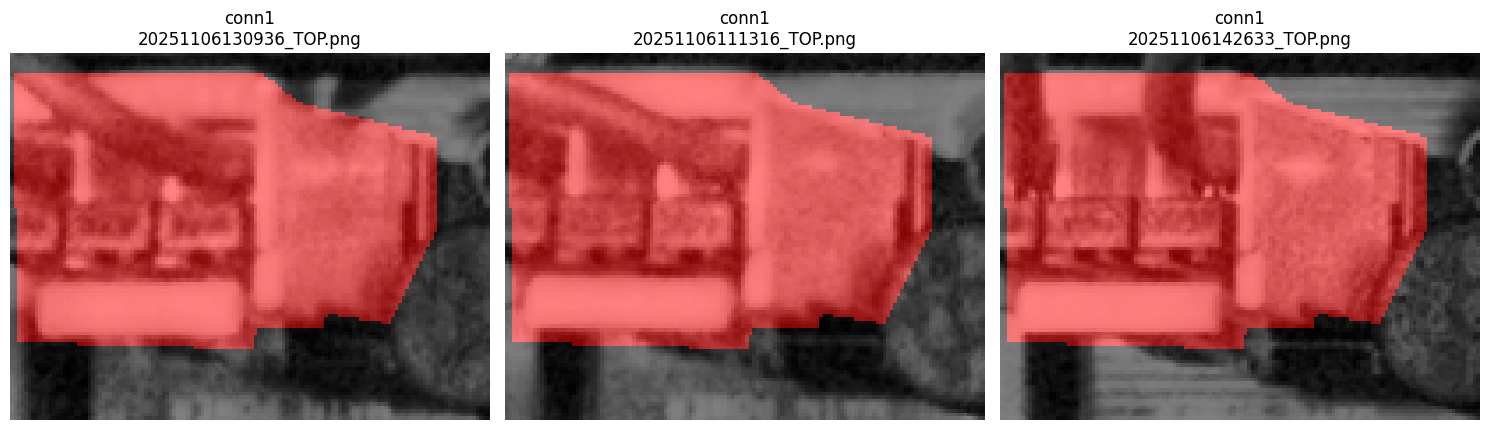

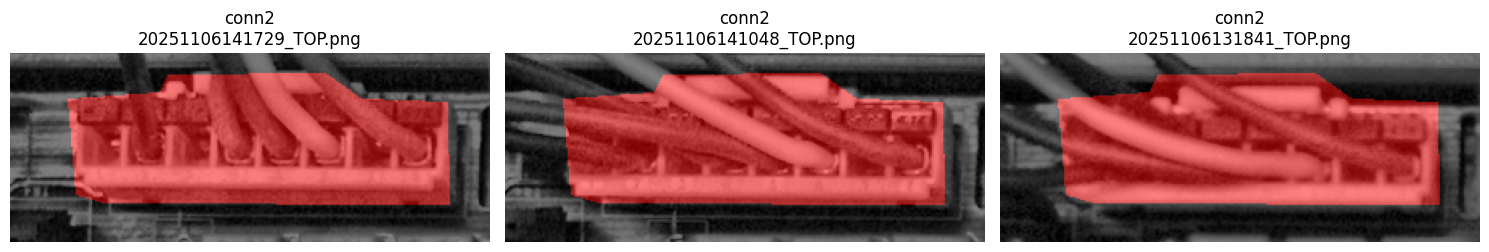

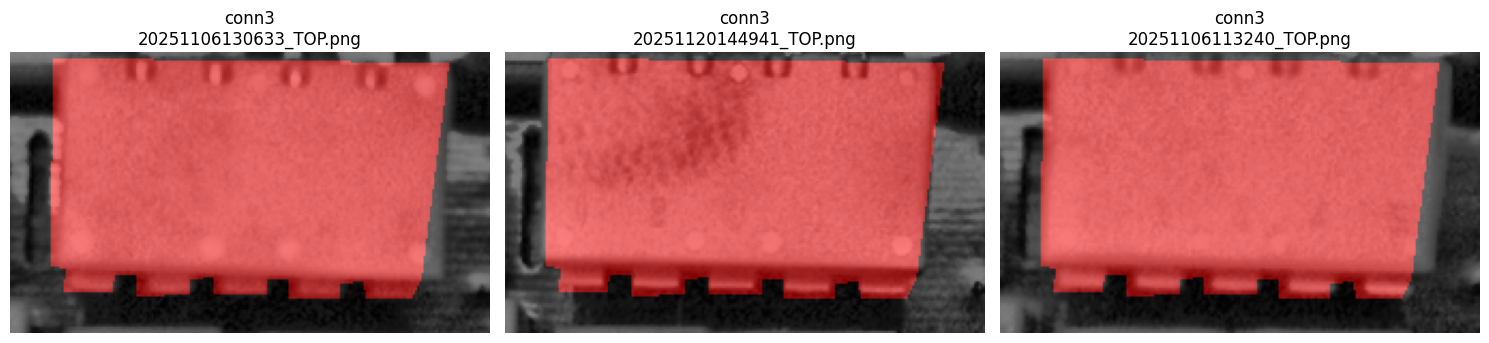

In [3]:
def overlay_mask_on_image(image: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    """Overlay mask on image with transparency."""
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    overlay = image.copy()
    mask_colored = np.zeros_like(image)
    mask_colored[mask > 0] = [255, 0, 0]  # Red overlay

    cv2.addWeighted(overlay, 1-alpha, mask_colored, alpha, 0, overlay)
    return overlay

def visualize_masks(connector_masks: Dict, connectors_root: Path, n_samples: int = 3):
    """Visualize mask overlays for sample images."""
    for conn_id, info in list(connector_masks.items())[:3]:  # Show first 3 connectors
        conn_dir = connectors_root / conn_id
        img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

        if len(img_files) < n_samples:
            n_samples = len(img_files)

        selected_files = random.sample(img_files, min(n_samples, len(img_files)))

        fig, axes = plt.subplots(1, n_samples, figsize=(5*n_samples, 5))
        if n_samples == 1:
            axes = [axes]

        for idx, img_path in enumerate(selected_files):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            overlay = overlay_mask_on_image(img, info['mask'])
            axes[idx].imshow(overlay)
            axes[idx].set_title(f"{conn_id}\n{img_path.name}")
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

visualize_masks(connector_masks, CONNECTORS_ROOT, n_samples=3)


## 4. Visual Debug: Fake-KO Preview


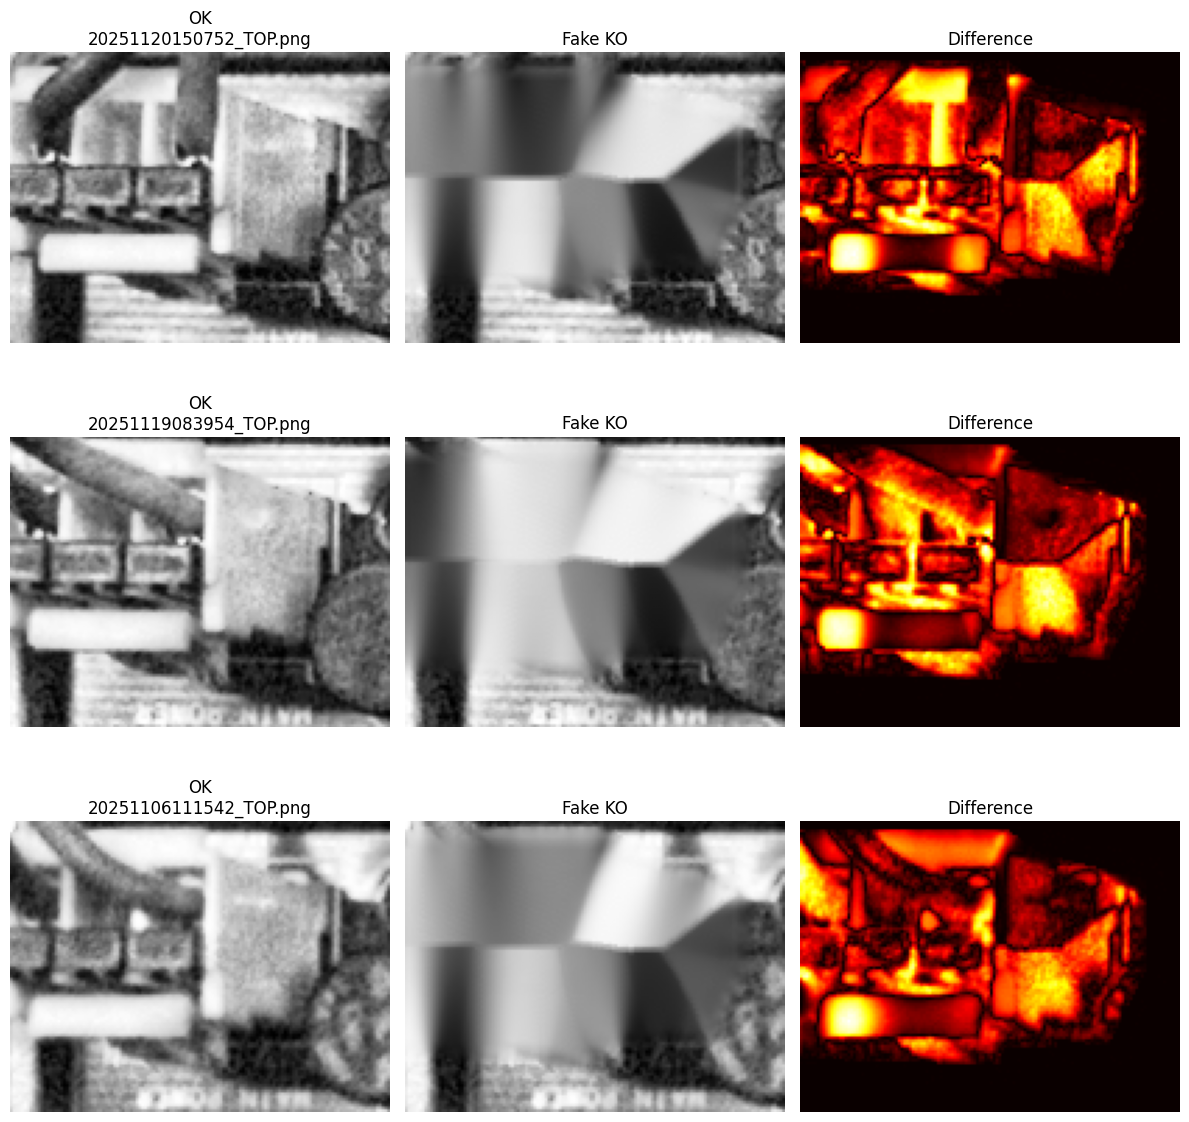

In [4]:
def generate_fake_ko(
    image: np.ndarray,
    mask: np.ndarray,
    inpaint_radius: int = DEFAULT_INPAINT_RADIUS,
    mask_dilate_px: int = DEFAULT_MASK_DILATE_PX,
    inpaint_method: int = cv2.INPAINT_TELEA,
    use_blending: bool = True
) -> np.ndarray:
    """
    Generate fake KO image by inpainting the PCL region.

    Args:
        image: Input grayscale or RGB image
        mask: Binary mask (255 where PCL is)
        inpaint_radius: Radius for inpainting
        mask_dilate_px: Pixels to dilate mask
        inpaint_method: cv2.INPAINT_TELEA or cv2.INPAINT_NS
        use_blending: Whether to apply boundary blending

    Returns:
        Fake KO image
    """
    # Convert to grayscale for processing
    if len(image.shape) == 3:
        img_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = image.copy()

    # Dilate mask
    if mask_dilate_px > 0:
        kernel = np.ones((mask_dilate_px*2+1, mask_dilate_px*2+1), np.uint8)
        mask_dilated = cv2.dilate(mask, kernel, iterations=1)
    else:
        mask_dilated = mask.copy()

    # Inpaint
    mask_inpaint = (mask_dilated > 0).astype(np.uint8) * 255
    inpainted = cv2.inpaint(img_gray, mask_inpaint, inpaint_radius, inpaint_method)

    # Boundary blending
    if use_blending:
        # Create alpha mask with Gaussian blur for smooth transition
        alpha_mask = mask_dilated.astype(np.float32) / 255.0
        alpha_mask = cv2.GaussianBlur(alpha_mask, (15, 15), 5)

        # Blend: alpha=1 in center (inpainted), alpha=0 outside (original)
        fake_ko = (alpha_mask * inpainted + (1 - alpha_mask) * img_gray).astype(np.uint8)
    else:
        fake_ko = inpainted

    # Convert back to original format if needed
    if len(image.shape) == 3:
        fake_ko = cv2.cvtColor(fake_ko, cv2.COLOR_GRAY2RGB)

    return fake_ko

def preview_fake_ko(connector_masks: Dict, connectors_root: Path, n_samples: int = 3):
    """Preview fake-KO generation for sample images."""
    conn_id = 'conn1'  # Focus on conn1 as specified
    if conn_id not in connector_masks:
        print(f"{conn_id} not found in connector_masks")
        return

    info = connector_masks[conn_id]
    conn_dir = connectors_root / conn_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    selected_files = random.sample(img_files, min(n_samples, len(img_files)))

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(selected_files):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        fake_ko = generate_fake_ko(
            img,
            info['mask'],
            inpaint_radius=info['inpaint_radius'],
            mask_dilate_px=info['mask_dilate_px']
        )

        diff = np.abs(img.astype(np.float32) - fake_ko.astype(np.float32))
        diff = (diff / diff.max() * 255).astype(np.uint8) if diff.max() > 0 else diff.astype(np.uint8)

        axes[idx, 0].imshow(img, cmap='gray')
        axes[idx, 0].set_title(f"OK\n{img_path.name}")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(fake_ko, cmap='gray')
        axes[idx, 1].set_title("Fake KO")
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(diff, cmap='hot')
        axes[idx, 2].set_title("Difference")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

preview_fake_ko(connector_masks, CONNECTORS_ROOT, n_samples=3)


## 5. PyTorch Dataset & Dataloader


In [5]:
class AugmentationTransform:
    """Light augmentations for both OK and fake-KO images."""

    def __init__(self, brightness_range: Tuple[float, float] = (0.9, 1.1),
                 contrast_range: Tuple[float, float] = (0.9, 1.1),
                 noise_std: float = 5.0,
                 blur_prob: float = 0.1):
        self.brightness_range = brightness_range
        self.contrast_range = contrast_range
        self.noise_std = noise_std
        self.blur_prob = blur_prob

    def __call__(self, image: np.ndarray) -> np.ndarray:
        """Apply random augmentations."""
        img = image.copy().astype(np.float32)

        # Brightness jitter
        brightness_factor = np.random.uniform(*self.brightness_range)
        img = img * brightness_factor

        # Contrast jitter
        contrast_factor = np.random.uniform(*self.contrast_range)
        mean = img.mean()
        img = (img - mean) * contrast_factor + mean

        # Gaussian noise
        noise = np.random.normal(0, self.noise_std, img.shape)
        img = img + noise

        # Optional slight blur
        if np.random.random() < self.blur_prob:
            img = cv2.GaussianBlur(img.astype(np.uint8), (3, 3), 0.5).astype(np.float32)

        # Clip to valid range
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

class PCLPresenceDataset(Dataset):
    """Dataset that generates fake-KO on-the-fly."""

    def __init__(
        self,
        image_paths: List[Path],
        mask: np.ndarray,
        inpaint_radius: int,
        mask_dilate_px: int,
        is_training: bool = True,
        use_augmentation: bool = True,
        grayscale_mode: bool = True
    ):
        self.image_paths = image_paths
        self.mask = mask
        self.inpaint_radius = inpaint_radius
        self.mask_dilate_px = mask_dilate_px
        self.is_training = is_training
        self.use_augmentation = use_augmentation
        self.grayscale_mode = grayscale_mode

        if use_augmentation:
            self.aug_transform = AugmentationTransform()

        # For diversity across epochs
        self.epoch = 0

    def set_epoch(self, epoch: int):
        """Set epoch for diverse fake-KO generation."""
        self.epoch = epoch

    def __len__(self) -> int:
        # Return double length: OK + fake-KO pairs
        return len(self.image_paths) * 2

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        # Determine if this is OK (label 0) or fake-KO (label 1)
        is_fake_ko = idx % 2 == 1
        img_idx = idx // 2

        # Load image
        img_path = self.image_paths[img_idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE if self.grayscale_mode else cv2.IMREAD_COLOR)

        if img is None:
            # Fallback: try PIL
            img = np.array(Image.open(img_path).convert('L' if self.grayscale_mode else 'RGB'))

        if is_fake_ko:
            # Generate fake-KO with diversity
            inpaint_method = cv2.INPAINT_TELEA if np.random.random() < 0.8 else cv2.INPAINT_NS
            radius_variation = np.random.uniform(0.8, 1.2)
            inpaint_radius = int(self.inpaint_radius * radius_variation)
            dilate_variation = np.random.randint(-1, 2)
            mask_dilate = max(0, self.mask_dilate_px + dilate_variation)

            img = generate_fake_ko(
                img, self.mask,
                inpaint_radius=inpaint_radius,
                mask_dilate_px=mask_dilate,
                inpaint_method=inpaint_method,
                use_blending=True
            )
            label = 1
        else:
            label = 0

        # Apply augmentations
        if self.use_augmentation and self.is_training:
            img = self.aug_transform(img)

        # Convert to tensor
        if self.grayscale_mode:
            if len(img.shape) == 2:
                img = img[np.newaxis, :, :]  # Add channel dimension
            else:
                img = img[:, :, 0:1].transpose(2, 0, 1)  # Take first channel
        else:
            if len(img.shape) == 2:
                img = np.stack([img, img, img], axis=0)  # Replicate to 3 channels
            else:
                img = img.transpose(2, 0, 1)

        img_tensor = torch.from_numpy(img).float() / 255.0

        return img_tensor, label

def create_dataloaders(
    connector_id: str,
    connector_info: Dict,
    connectors_root: Path,
    train_val_split: float = DEFAULT_TRAIN_VAL_SPLIT,
    batch_size: int = DEFAULT_BATCH_SIZE,
    num_workers: int = 2
) -> Tuple[DataLoader, DataLoader]:
    """Create train and validation dataloaders."""
    conn_dir = connectors_root / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    if not img_files:
        raise ValueError(f"No images found for {connector_id}")

    # Split into train/val
    split_idx = int(len(img_files) * train_val_split)
    train_files = img_files[:split_idx]
    val_files = img_files[split_idx:]

    print(f"  Train images: {len(train_files)}, Val images: {len(val_files)}")

    # Create datasets
    train_dataset = PCLPresenceDataset(
        train_files,
        connector_info['mask'],
        connector_info['inpaint_radius'],
        connector_info['mask_dilate_px'],
        is_training=True,
        use_augmentation=True
    )

    val_dataset = PCLPresenceDataset(
        val_files,
        connector_info['mask'],
        connector_info['inpaint_radius'],
        connector_info['mask_dilate_px'],
        is_training=False,
        use_augmentation=False
    )

    # Create dataloaders with balanced sampling
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )

    return train_loader, val_loader


## 6. Model Definition


## Debug & Visualization (Presentation)

This section provides visual explanations and analysis of the trained models.


Connector: conn1
Number of images: 312
Image size: 136x104
Mask area: 57.58%


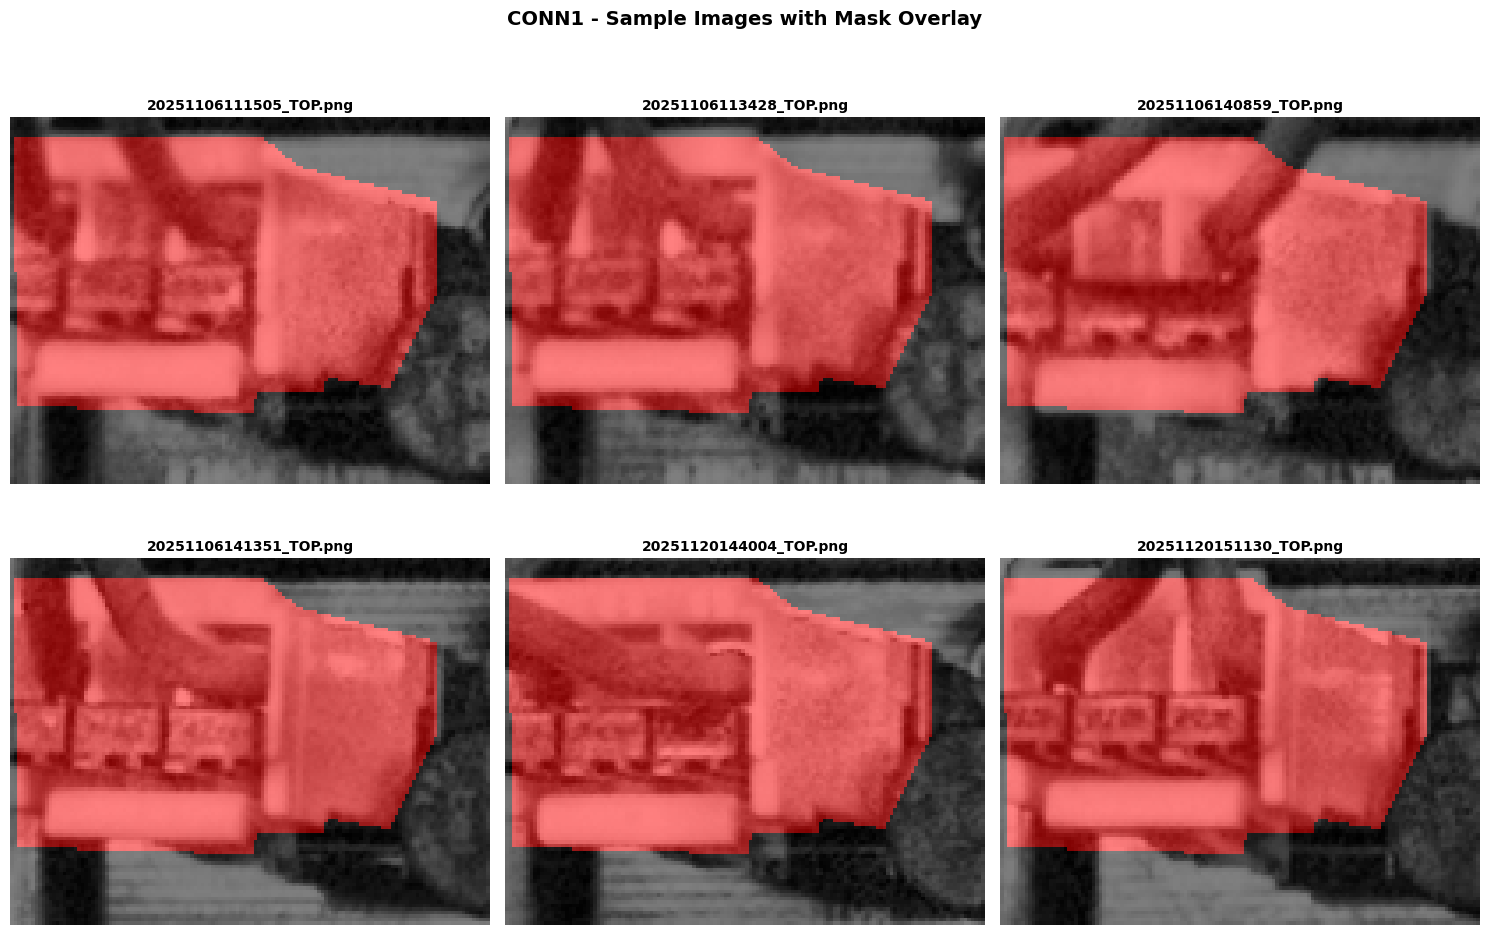

In [6]:
# CELL A — Connector overview + examples
connector_id = "conn1"  # Change this to visualize different connectors

conn_dir = CONNECTORS_ROOT / connector_id
img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

if connector_id not in connector_masks:
    print(f"Error: {connector_id} not found in connector_masks")
else:
    info = connector_masks[connector_id]
    mask = info['mask']
    img_size = info['image_size']

    # Calculate mask area percentage
    mask_area = np.sum(mask > 0)
    total_pixels = mask.size
    area_pct = (mask_area / total_pixels) * 100

    print(f"Connector: {connector_id}")
    print(f"Number of images: {len(img_files)}")
    print(f"Image size: {img_size[0]}x{img_size[1]}")
    print(f"Mask area: {area_pct:.2f}%")
    print("="*60)

    # Show grid of 6 random OK images with mask overlay
    n_samples = min(6, len(img_files))
    selected_files = random.sample(img_files, n_samples)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(selected_files):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(img_path).convert('L'))

        # Overlay mask
        overlay = overlay_mask_on_image(img, mask, alpha=0.5)

        axes[idx].imshow(overlay)
        axes[idx].set_title(f"{img_path.name}", fontsize=10, weight='bold')
        axes[idx].axis('off')

    plt.suptitle(f"{connector_id.upper()} - Sample Images with Mask Overlay",
                 fontsize=14, weight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


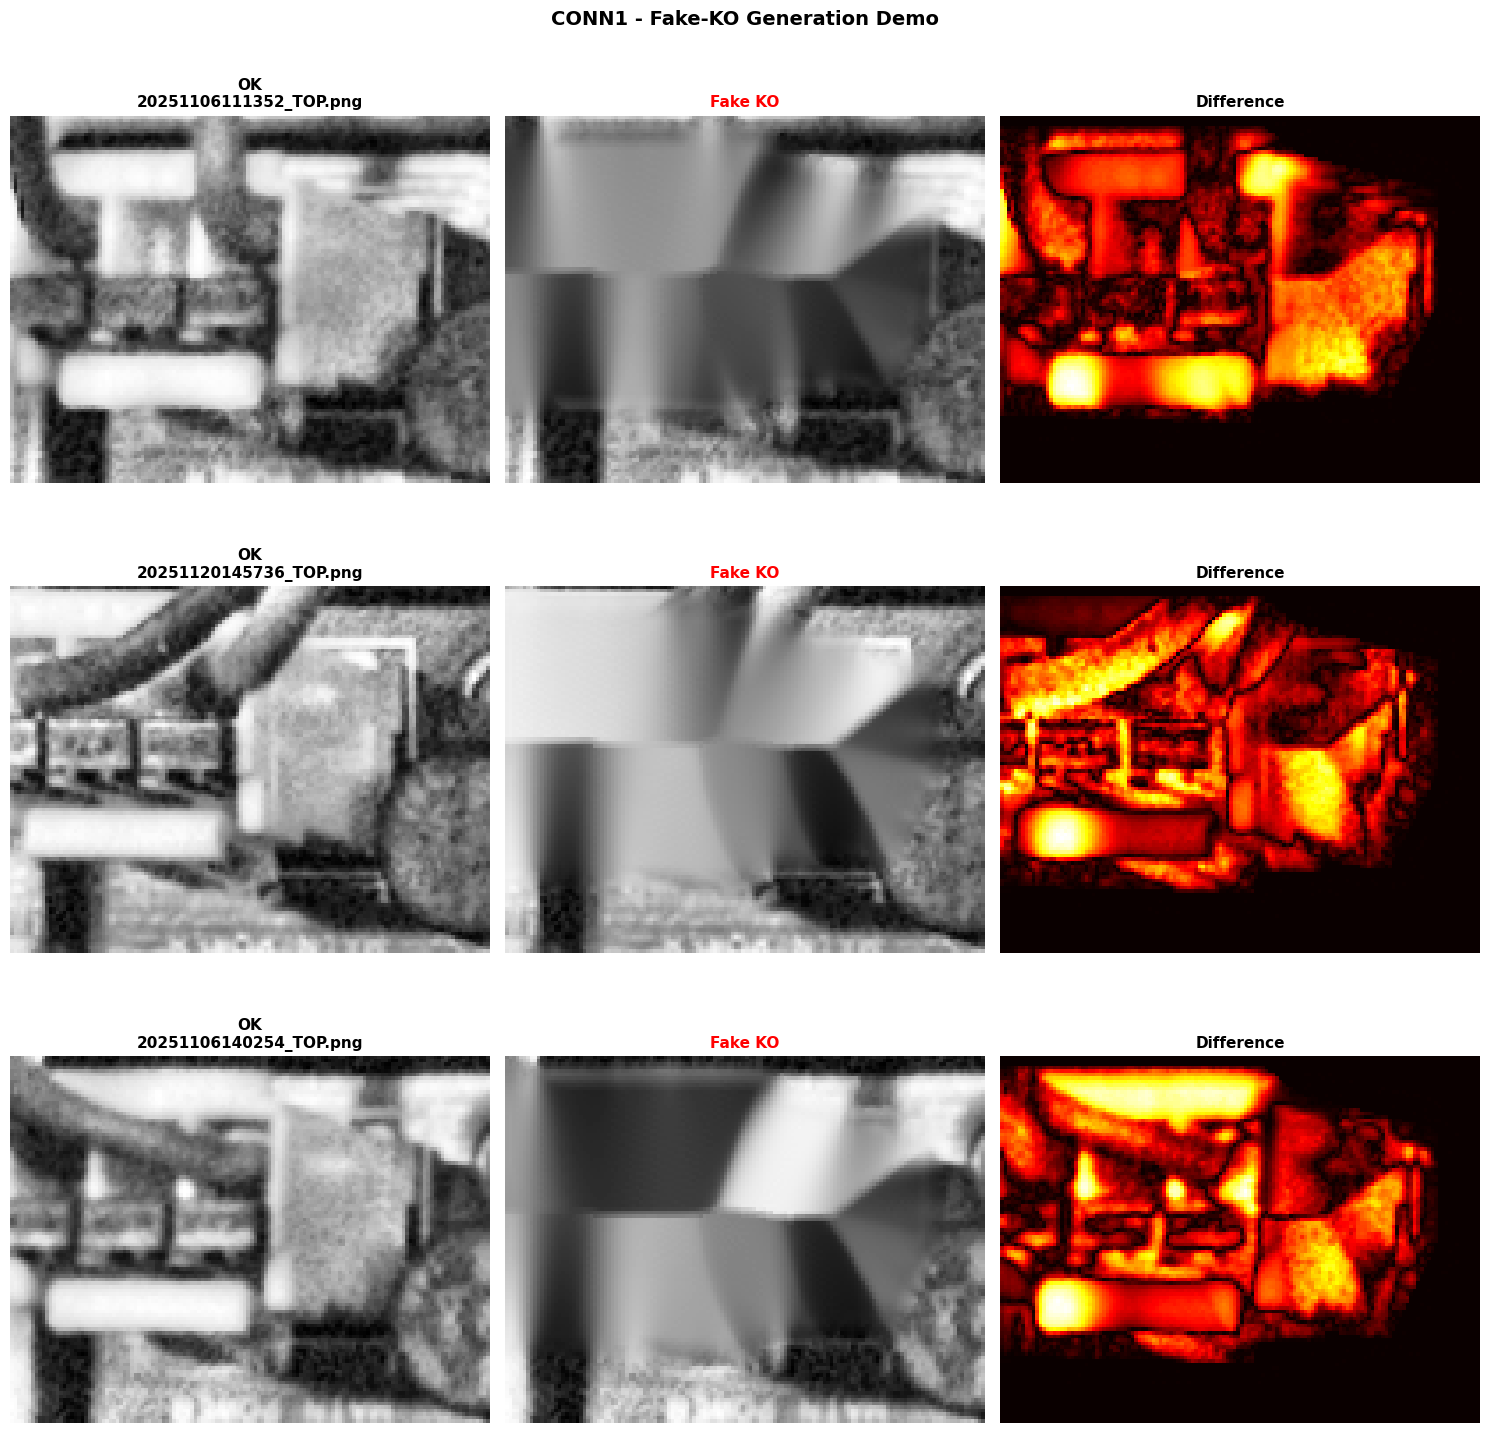

In [7]:
# CELL B — Fake-KO generation demo
connector_id = "conn1"  # Change this to visualize different connectors

if connector_id not in connector_masks:
    print(f"Error: {connector_id} not found in connector_masks")
else:
    info = connector_masks[connector_id]
    conn_dir = CONNECTORS_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    # Pick 3 random OK images
    n_samples = min(3, len(img_files))
    selected_files = random.sample(img_files, n_samples)

    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(selected_files):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(img_path).convert('L'))

        # Generate fake KO
        fake_ko = generate_fake_ko(
            img,
            info['mask'],
            inpaint_radius=info['inpaint_radius'],
            mask_dilate_px=info['mask_dilate_px']
        )

        # Difference heatmap
        diff = np.abs(img.astype(np.float32) - fake_ko.astype(np.float32))
        diff_normalized = (diff / diff.max() * 255).astype(np.uint8) if diff.max() > 0 else diff.astype(np.uint8)

        # Display
        axes[idx, 0].imshow(img, cmap='gray')
        axes[idx, 0].set_title(f"OK\n{img_path.name}", fontsize=11, weight='bold')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(fake_ko, cmap='gray')
        axes[idx, 1].set_title("Fake KO", fontsize=11, weight='bold', color='red')
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(diff_normalized, cmap='hot')
        axes[idx, 2].set_title("Difference", fontsize=11, weight='bold')
        axes[idx, 2].axis('off')

    plt.suptitle(f"{connector_id.upper()} - Fake-KO Generation Demo",
                 fontsize=14, weight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


In [8]:
# CELL C — Real OK vs Real KO gallery (if Test folder exists)
connector_id = "conn1"  # Change this to visualize different connectors

# Check for Test folder
test_folder = CONNECTORS_ROOT / connector_id / "Test"
if not test_folder.exists():
    print(f"No Test folder found for {connector_id}")
    print("Skipping real OK vs KO gallery visualization")
else:
    # Load model and threshold
    try:
        model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
        info = connector_masks[connector_id]

        # Get all images from Test folder
        test_images = sorted(list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpg")))

        if not test_images:
            print(f"No images found in Test folder for {connector_id}")
        else:
            # Run inference for all images
            print(f"Running inference on {len(test_images)} test images...")
            results = []

            for img_path in tqdm(test_images):
                prob_ko, is_ko = predict_connector(
                    img_path, connector_id, model, info, threshold, device
                )
                results.append({
                    'path': img_path,
                    'prob_ko': prob_ko,
                    'is_ko': is_ko
                })

            # Sort by prob_ko
            results_sorted = sorted(results, key=lambda x: x['prob_ko'])

            # Get 10 highest (KO) and 10 lowest (OK)
            lowest_10 = results_sorted[:10]
            highest_10 = results_sorted[-10:]

            # Display gallery
            fig, axes = plt.subplots(2, 10, figsize=(20, 4))

            # Lowest 10 (OK predictions)
            for idx, result in enumerate(lowest_10):
                img = cv2.imread(str(result['path']), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(result['path']).convert('L'))

                axes[0, idx].imshow(img, cmap='gray')
                axes[0, idx].set_title(f"{result['path'].name[:15]}...\np_ko={result['prob_ko']:.3f}",
                                       fontsize=8, color='green')
                axes[0, idx].axis('off')

            axes[0, 0].set_ylabel("Lowest prob_ko (OK)", fontsize=12, weight='bold', color='green')

            # Highest 10 (KO predictions)
            for idx, result in enumerate(highest_10):
                img = cv2.imread(str(result['path']), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(result['path']).convert('L'))

                axes[1, idx].imshow(img, cmap='gray')
                axes[1, idx].set_title(f"{result['path'].name[:15]}...\np_ko={result['prob_ko']:.3f}",
                                       fontsize=8, color='red')
                axes[1, idx].axis('off')

            axes[1, 0].set_ylabel("Highest prob_ko (KO)", fontsize=12, weight='bold', color='red')

            plt.suptitle(f"{connector_id.upper()} - Real OK vs Real KO Gallery (Test Set)",
                         fontsize=14, weight='bold')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error loading model or processing Test folder: {e}")
        import traceback
        traceback.print_exc()


No Test folder found for conn1
Skipping real OK vs KO gallery visualization


In [9]:
# CELL D — Score distribution plot + threshold
connector_id = "conn1"  # Change this to visualize different connectors

try:
    # Load model and threshold
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get images from Data/connectors/<connector_id>/ and optionally Test/
    conn_dir = CONNECTORS_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    # Optionally add Test folder images
    test_folder = conn_dir / "Test"
    if test_folder.exists():
        test_images = sorted(list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpg")))
        img_files.extend(test_images)

    print(f"Computing prob_ko for {len(img_files)} images...")

    # Compute prob_ko for all images
    all_probs = []
    all_predictions = []

    for img_path in tqdm(img_files):
        prob_ko, is_ko = predict_connector(
            img_path, connector_id, model, info, threshold, device
        )
        all_probs.append(prob_ko)
        all_predictions.append('KO' if is_ko else 'OK')

    all_probs = np.array(all_probs)
    all_predictions = np.array(all_predictions)

    # Separate OK and KO predictions
    ok_probs = all_probs[all_predictions == 'OK']
    ko_probs = all_probs[all_predictions == 'KO']

    # Plot histogram
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    if len(ok_probs) > 0:
        ax.hist(ok_probs, bins=50, alpha=0.7, label=f'Predicted OK (n={len(ok_probs)})',
                color='green', edgecolor='black')

    if len(ko_probs) > 0:
        ax.hist(ko_probs, bins=50, alpha=0.7, label=f'Predicted KO (n={len(ko_probs)})',
                color='red', edgecolor='black')

    # Draw threshold line
    ax.axvline(threshold, color='blue', linestyle='--', linewidth=2,
               label=f'Threshold = {threshold:.4f}')

    ax.set_xlabel('Probability KO', fontsize=12, weight='bold')
    ax.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax.set_title(f'{connector_id.upper()} - Score Distribution', fontsize=14, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("Score Distribution Summary")
    print("="*60)

    if len(ok_probs) > 0:
        print(f"Predicted OK:")
        print(f"  Min:   {np.min(ok_probs):.4f}")
        print(f"  Mean:  {np.mean(ok_probs):.4f}")
        print(f"  Max:   {np.max(ok_probs):.4f}")

    if len(ko_probs) > 0:
        print(f"\nPredicted KO:")
        print(f"  Min:   {np.min(ko_probs):.4f}")
        print(f"  Mean:  {np.mean(ko_probs):.4f}")
        print(f"  Max:   {np.max(ko_probs):.4f}")

    if len(ok_probs) > 0 and len(ko_probs) > 0:
        gap = np.min(ko_probs) - np.max(ok_probs)
        print(f"\nGAP (minKO - maxOK): {gap:.4f}")
        if gap > 0:
            print("✅ Good separation between OK and KO")
        else:
            print("⚠️  Overlap between OK and KO distributions")

    print(f"\nThreshold: {threshold:.4f}")
    print("="*60)

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


Error: name 'load_trained_model' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-2703698882.py", line 6, in <cell line: 0>
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
                       ^^^^^^^^^^^^^^^^^^
NameError: name 'load_trained_model' is not defined


In [10]:
# CELL E — Borderline cases
connector_id = "conn1"  # Change this to visualize different connectors

try:
    # Load model and threshold
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get images from Data/connectors/<connector_id>/ and optionally Test/
    conn_dir = CONNECTORS_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    test_folder = conn_dir / "Test"
    if test_folder.exists():
        test_images = sorted(list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpg")))
        img_files.extend(test_images)

    print(f"Finding borderline cases from {len(img_files)} images...")

    # Compute prob_ko and distance from threshold
    borderline_data = []

    for img_path in tqdm(img_files):
        prob_ko, is_ko = predict_connector(
            img_path, connector_id, model, info, threshold, device
        )
        distance_from_threshold = abs(prob_ko - threshold)
        borderline_data.append({
            'path': img_path,
            'prob_ko': prob_ko,
            'distance': distance_from_threshold
        })

    # Sort by distance from threshold (closest first)
    borderline_data.sort(key=lambda x: x['distance'])

    # Get 12 closest to threshold
    n_borderline = min(12, len(borderline_data))
    borderline_samples = borderline_data[:n_borderline]

    # Display as grid
    n_cols = 4
    n_rows = (n_borderline + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for idx, sample in enumerate(borderline_samples):
        img = cv2.imread(str(sample['path']), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(sample['path']).convert('L'))

        axes[idx].imshow(img, cmap='gray')

        # Color based on prediction
        pred_color = 'red' if sample['prob_ko'] > threshold else 'green'
        title = f"{sample['path'].name[:20]}...\np_ko={sample['prob_ko']:.4f}\ndist={sample['distance']:.4f}"
        axes[idx].set_title(title, fontsize=9, color=pred_color, weight='bold')
        axes[idx].axis('off')

    # Hide unused axes
    for idx in range(n_borderline, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'{connector_id.upper()} - Borderline Cases (Closest to Threshold)',
                 fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nShowing {n_borderline} samples closest to threshold {threshold:.4f}")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


Error: name 'load_trained_model' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-3150554500.py", line 6, in <cell line: 0>
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
                       ^^^^^^^^^^^^^^^^^^
NameError: name 'load_trained_model' is not defined


In [11]:
# CELL F — Grad-CAM / Saliency visualization
connector_id = "conn1"  # Change this to visualize different connectors

try:
    # Load model
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get test images (or use connector images)
    conn_dir = CONNECTORS_ROOT / connector_id
    test_folder = conn_dir / "Test"

    if test_folder.exists():
        test_images = sorted(list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpg")))
    else:
        test_images = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    if not test_images:
        print(f"No images found for {connector_id}")
    else:
        # Run inference to get OK and KO samples
        results = []
        for img_path in test_images[:50]:  # Limit to first 50 for speed
            prob_ko, is_ko = predict_connector(
                img_path, connector_id, model, info, threshold, device
            )
            results.append({
                'path': img_path,
                'prob_ko': prob_ko,
                'is_ko': is_ko
            })

        # Sort and get 3 OK and 3 KO
        results_sorted = sorted(results, key=lambda x: x['prob_ko'])
        ok_samples = [r for r in results_sorted if not r['is_ko']][:3]
        ko_samples = [r for r in results_sorted if r['is_ko']][-3:]

        if len(ok_samples) == 0 or len(ko_samples) == 0:
            print("Need both OK and KO samples for visualization")
        else:
            # Implement Grad-CAM
            def generate_gradcam(model, image_tensor, target_layer):
                """Generate Grad-CAM heatmap."""
                model.eval()

                # Register hook for gradients
                gradients = []
                activations = []

                def backward_hook(module, grad_input, grad_output):
                    gradients.append(grad_output[0])

                def forward_hook(module, input, output):
                    activations.append(output)

                hook_handle = target_layer.register_backward_hook(backward_hook)
                forward_handle = target_layer.register_forward_hook(forward_hook)

                # Forward pass
                output = model(image_tensor)

                # Backward pass
                model.zero_grad()
                output.backward(torch.ones_like(output))

                # Get gradients and activations
                grads = gradients[0]
                acts = activations[0]

                # Global average pooling of gradients
                weights = torch.mean(grads, dim=(2, 3), keepdim=True)

                # Weighted combination of activation maps
                cam = torch.sum(weights * acts, dim=1, keepdim=True)
                cam = torch.relu(cam)

                # Normalize
                cam = cam.squeeze().cpu().numpy()
                cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

                # Resize to input size
                cam_resized = cv2.resize(cam, (image_tensor.shape[3], image_tensor.shape[2]))

                hook_handle.remove()
                forward_handle.remove()

                return cam_resized

            # Get target layer (layer4 of ResNet18)
            target_layer = model.backbone.layer4

            # Visualize
            fig, axes = plt.subplots(2, 6, figsize=(18, 6))

            # OK samples
            for idx, sample in enumerate(ok_samples):
                img_path = sample['path']
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                # Preprocess for model
                img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
                img_tensor = img_tensor.to(device)

                # Generate Grad-CAM
                try:
                    cam = generate_gradcam(model, img_tensor, target_layer)

                    # Overlay heatmap
                    cam_colored = plt.cm.jet(cam)[:, :, :3]
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
                    overlay = 0.6 * img_rgb + 0.4 * cam_colored

                    axes[0, idx].imshow(img, cmap='gray')
                    axes[0, idx].set_title(f"OK\n{sample['path'].name[:15]}...\np={sample['prob_ko']:.3f}",
                                           fontsize=9, color='green', weight='bold')
                    axes[0, idx].axis('off')

                    axes[1, idx].imshow(overlay)
                    axes[1, idx].set_title("Grad-CAM", fontsize=9, weight='bold')
                    axes[1, idx].axis('off')
                except Exception as e:
                    print(f"Error generating Grad-CAM for {img_path.name}: {e}")
                    axes[0, idx].text(0.5, 0.5, "Error", ha='center', va='center')
                    axes[1, idx].text(0.5, 0.5, "Error", ha='center', va='center')

            # KO samples
            for idx, sample in enumerate(ko_samples):
                img_path = sample['path']
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                # Preprocess for model
                img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
                img_tensor = img_tensor.to(device)

                # Generate Grad-CAM
                try:
                    cam = generate_gradcam(model, img_tensor, target_layer)

                    # Overlay heatmap
                    cam_colored = plt.cm.jet(cam)[:, :, :3]
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
                    overlay = 0.6 * img_rgb + 0.4 * cam_colored

                    axes[0, idx+3].imshow(img, cmap='gray')
                    axes[0, idx+3].set_title(f"KO\n{sample['path'].name[:15]}...\np={sample['prob_ko']:.3f}",
                                             fontsize=9, color='red', weight='bold')
                    axes[0, idx+3].axis('off')

                    axes[1, idx+3].imshow(overlay)
                    axes[1, idx+3].set_title("Grad-CAM", fontsize=9, weight='bold')
                    axes[1, idx+3].axis('off')
                except Exception as e:
                    print(f"Error generating Grad-CAM for {img_path.name}: {e}")
                    axes[0, idx+3].text(0.5, 0.5, "Error", ha='center', va='center')
                    axes[1, idx+3].text(0.5, 0.5, "Error", ha='center', va='center')

            plt.suptitle(f'{connector_id.upper()} - Grad-CAM Visualization (Layer4)',
                        fontsize=14, weight='bold')
            plt.tight_layout()
            plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


Error: name 'load_trained_model' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-1755936636.py", line 6, in <cell line: 0>
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
                       ^^^^^^^^^^^^^^^^^^
NameError: name 'load_trained_model' is not defined


In [12]:
# CELL G — Multi-connector summary visualization
print("="*80)
print("Multi-Connector Summary")
print("="*80)

# Scan outputs/pcl_presence/*
summary_data = []

for conn_dir in OUTPUT_ROOT.iterdir():
    if not conn_dir.is_dir():
        continue

    connector_id = conn_dir.name

    # Load threshold
    threshold_path = conn_dir / "threshold.json"
    if not threshold_path.exists():
        continue

    with open(threshold_path, 'r') as f:
        threshold_data = json.load(f)
    threshold = threshold_data['threshold']

    # Count images (from Data with KO folder for analysis)
    conn_data_dir = CONNECTORS_WITH_KO_ROOT / connector_id
    if conn_data_dir.exists():
        img_files = list(conn_data_dir.glob("*.png")) + list(conn_data_dir.glob("*.jpg"))
        n_images = len(img_files)
    else:
        n_images = 0

    # Load config for notes
    config_path = conn_dir / "training_config.json"
    notes = ""
    if config_path.exists():
        with open(config_path, 'r') as f:
            config = json.load(f)
            notes = f"AUC={config.get('final_val_auc', 'N/A'):.3f}" if config.get('final_val_auc') else ""

    summary_data.append({
        'connector_id': connector_id,
        'threshold': threshold,
        'n_images': n_images,
        'notes': notes
    })

# Sort by connector number
summary_data.sort(key=lambda x: int(x['connector_id'][4:]) if x['connector_id'][4:].isdigit() else 999)

# Print table
print(f"{'Connector':<12} {'Threshold':<12} {'# Images':<10} {'Notes':<20}")
print("-"*80)

for data in summary_data:
    threshold_str = f"{data['threshold']:.4f}"
    print(f"{data['connector_id']:<12} {threshold_str:<12} {data['n_images']:<10} {data['notes']:<20}")

print("="*80)

# Plot thresholds as bar plot
if len(summary_data) > 0:
    connectors = [d['connector_id'] for d in summary_data]
    thresholds = [d['threshold'] for d in summary_data]

    fig, ax = plt.subplots(1, 1, figsize=(max(10, len(connectors)*1.2), 6))

    bars = ax.bar(connectors, thresholds, color='steelblue', edgecolor='black', linewidth=1.5)

    # Add value labels on bars
    for bar, thresh in zip(bars, thresholds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{thresh:.4f}',
               ha='center', va='bottom', fontsize=9, weight='bold')

    ax.set_xlabel('Connector', fontsize=12, weight='bold')
    ax.set_ylabel('Threshold', fontsize=12, weight='bold')
    ax.set_title('Thresholds Across Connectors', fontsize=14, weight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nTotal connectors trained: {len(summary_data)}")
else:
    print("\nNo trained connectors found in outputs/pcl_presence/")


Multi-Connector Summary
Connector    Threshold    # Images   Notes               
--------------------------------------------------------------------------------

No trained connectors found in outputs/pcl_presence/


In [13]:
class PCLPresenceClassifier(nn.Module):
    """ResNet18-based binary classifier for PCL presence detection."""

    def __init__(self, input_channels: int = 1, pretrained: bool = True):
        super().__init__()
        # Load pretrained ResNet18 (support both old and new PyTorch versions)
        try:
            # New API (torchvision >= 0.13)
            from torchvision.models import ResNet18_Weights
            weights = ResNet18_Weights.DEFAULT if pretrained else None
            self.backbone = resnet18(weights=weights)
        except (ImportError, AttributeError):
            # Old API (torchvision < 0.13)
            self.backbone = resnet18(pretrained=pretrained)

        # Modify first layer for grayscale input
        if input_channels == 1:
            # Replace first conv layer
            self.backbone.conv1 = nn.Conv2d(
                1, 64, kernel_size=7, stride=2, padding=3, bias=False
            )
        elif input_channels == 3:
            # Keep original (already 3 channels)
            pass
        else:
            raise ValueError(f"Unsupported input_channels: {input_channels}")

        # Replace classifier head for binary classification
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

def create_model(input_channels: int = 1, pretrained: bool = True) -> nn.Module:
    """Create and return the model."""
    model = PCLPresenceClassifier(input_channels=input_channels, pretrained=pretrained)
    return model

# Test model creation
test_model = create_model(input_channels=1, pretrained=True)
print("Model architecture:")
print(test_model)

# Count parameters
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


Model architecture:
PCLPresenceClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, m

## 7. Training Loop


In [14]:
def train_epoch(model: nn.Module, train_loader: DataLoader, criterion: nn.Module,
                optimizer: optim.Optimizer, device: torch.device) -> float:
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches if num_batches > 0 else 0.0

def validate(model: nn.Module, val_loader: DataLoader, criterion: nn.Module,
             device: torch.device) -> Tuple[float, List[float], List[int]]:
    """Validate model and return loss, predictions, and labels."""
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader) if len(val_loader) > 0 else 0.0
    return avg_loss, all_probs, all_labels

def train_model(
    connector_id: str,
    connector_info: Dict,
    connectors_root: Path,
    epochs: int = DEFAULT_EPOCHS,
    batch_size: int = DEFAULT_BATCH_SIZE,
    learning_rate: float = DEFAULT_LEARNING_RATE,
    train_val_split: float = DEFAULT_TRAIN_VAL_SPLIT
) -> Tuple[nn.Module, Dict]:
    """Train model for a single connector."""
    print(f"\n{'='*60}")
    print(f"Training model for {connector_id}")
    print(f"{'='*60}")

    # Create dataloaders
    train_loader, val_loader = create_dataloaders(
        connector_id, connector_info, connectors_root,
        train_val_split=train_val_split,
        batch_size=batch_size
    )

    # Create model
    model = create_model(input_channels=1, pretrained=True)
    model = model.to(device)

    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_auc': []
    }

    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    # Training loop
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Update dataset epoch for diversity
        train_loader.dataset.set_epoch(epoch)

        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_probs, val_labels = validate(model, val_loader, criterion, device)

        # Calculate AUC
        try:
            val_auc = roc_auc_score(val_labels, val_probs)
        except:
            val_auc = 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return model, history


## 8. Threshold Calibration (Real OK Only)


In [15]:
def calibrate_threshold(
    model: nn.Module,
    val_ok_images: List[Path],
    connector_info: Dict,
    device: torch.device,
    percentile: float = DEFAULT_THRESHOLD_PERCENTILE
) -> float:
    """
    Calibrate threshold using ONLY real OK validation images.
    Returns threshold at specified percentile of KO probabilities.
    """
    model.eval()
    ko_probs = []

    # Create a simple dataset for OK images only
    dataset = PCLPresenceDataset(
        val_ok_images,
        connector_info['mask'],
        connector_info['inpaint_radius'],
        connector_info['mask_dilate_px'],
        is_training=False,
        use_augmentation=False
    )

    with torch.no_grad():
        for idx in range(len(val_ok_images)):
            # Get OK image (even indices)
            image, _ = dataset[idx * 2]  # OK images are at even indices
            image = image.unsqueeze(0).to(device)

            output = model(image).squeeze()
            prob_ko = torch.sigmoid(output).item()
            ko_probs.append(prob_ko)

    threshold = np.percentile(ko_probs, percentile)
    false_positive_rate = np.mean(np.array(ko_probs) > threshold) * 100

    print(f"\nThreshold Calibration (Real OK Only):")
    print(f"  Percentile: {percentile}%")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  Expected FPR on OK: {false_positive_rate:.2f}%")
    print(f"  Min KO prob: {np.min(ko_probs):.4f}")
    print(f"  Max KO prob: {np.max(ko_probs):.4f}")
    print(f"  Mean KO prob: {np.mean(ko_probs):.4f}")

    return threshold, false_positive_rate


## 9. Inference Helper


In [16]:
def predict_connector(
    image_path: Union[str, Path],
    connector_id: str,
    model: nn.Module,
    connector_info: Dict,
    threshold: float,
    device: torch.device
) -> Tuple[float, bool]:
    """
    Predict PCL presence for a single image.

    Returns:
        (prob_ko, is_ko): KO probability and binary prediction
    """
    model.eval()

    # Load image
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.array(Image.open(image_path).convert('L'))

    # Preprocess
    if len(img.shape) == 2:
        img = img[np.newaxis, :, :]
    else:
        img = img[:, :, 0:1].transpose(2, 0, 1)

    img_tensor = torch.from_numpy(img).float().unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(device)

    # Predict
    with torch.no_grad():
        output = model(img_tensor).squeeze()
        prob_ko = torch.sigmoid(output).item()

    is_ko = prob_ko > threshold

    return prob_ko, is_ko


## 10. Save Artifacts


In [17]:
def save_artifacts(
    connector_id: str,
    model: nn.Module,
    threshold: float,
    fpr_estimate: float,
    history: Dict,
    connector_info: Dict,
    output_root: Path
):
    """Save model weights, threshold, and training config."""
    output_dir = output_root / connector_id
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save model weights
    model_path = output_dir / "model.pt"
    torch.save(model.state_dict(), model_path)
    print(f"Saved model to: {model_path}")

    # Save threshold
    threshold_data = {
        'threshold': float(threshold),
        'percentile': DEFAULT_THRESHOLD_PERCENTILE,
        'val_ok_fpr_estimate': float(fpr_estimate)
    }
    threshold_path = output_dir / "threshold.json"
    with open(threshold_path, 'w') as f:
        json.dump(threshold_data, f, indent=2)
    print(f"Saved threshold to: {threshold_path}")

    # Save training config summary
    config_summary = {
        'connector_id': connector_id,
        'image_size': connector_info['image_size'],
        'inpaint_radius': connector_info['inpaint_radius'],
        'mask_dilate_px': connector_info['mask_dilate_px'],
        'threshold': float(threshold),
        'val_ok_fpr_estimate': float(fpr_estimate),
        'final_train_loss': history['train_loss'][-1] if history['train_loss'] else None,
        'final_val_loss': history['val_loss'][-1] if history['val_loss'] else None,
        'final_val_auc': history['val_auc'][-1] if history['val_auc'] else None,
        'num_epochs_trained': len(history['train_loss'])
    }
    config_path = output_dir / "training_config.json"
    with open(config_path, 'w') as f:
        json.dump(config_summary, f, indent=2)
    print(f"Saved config to: {config_path}")


## 11. Multi-Connector Training Loop


In [18]:
def train_all_connectors(
    connector_masks: Dict,
    connectors_root: Path,
    output_root: Path,
    epochs: int = DEFAULT_EPOCHS,
    batch_size: int = DEFAULT_BATCH_SIZE,
    learning_rate: float = DEFAULT_LEARNING_RATE
) -> List[Dict]:
    """Train models for all connectors and return summary."""
    results = []

    # Get all connector directories
    all_connectors = sorted([d.name for d in connectors_root.iterdir()
                             if d.is_dir() and d.name.startswith('conn')])

    for conn_id in all_connectors:
        try:
            print(f"\n{'='*80}")
            print(f"Processing {conn_id}")
            print(f"{'='*80}")

            # Count images
            conn_dir = connectors_root / conn_id
            img_files = list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg"))
            n_images = len(img_files)

            # Check if connector has mask config
            if conn_id not in connector_masks:
                results.append({
                    'connector_id': conn_id,
                    'n_images': n_images,
                    'threshold': None,
                    'val_ok_fpr_estimate': None,
                    'status': 'SKIPPED',
                    'reason': 'No mask config or size mismatch'
                })
                print(f"Skipping {conn_id}: No mask config or image size mismatch")
                continue

            if n_images == 0:
                results.append({
                    'connector_id': conn_id,
                    'n_images': 0,
                    'threshold': None,
                    'val_ok_fpr_estimate': None,
                    'status': 'SKIPPED',
                    'reason': 'No images found'
                })
                print(f"Skipping {conn_id}: No images found")
                continue

            conn_info = connector_masks[conn_id]

            # Train model
            model, history = train_model(
                conn_id, conn_info, connectors_root,
                epochs=epochs,
                batch_size=batch_size,
                learning_rate=learning_rate
            )

            # Get validation OK images for threshold calibration
            img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))
            split_idx = int(len(img_files) * DEFAULT_TRAIN_VAL_SPLIT)
            val_ok_images = img_files[split_idx:]

            # Calibrate threshold
            threshold, fpr_estimate = calibrate_threshold(
                model, val_ok_images, conn_info, device,
                percentile=DEFAULT_THRESHOLD_PERCENTILE
            )

            # Save artifacts
            save_artifacts(conn_id, model, threshold, fpr_estimate, history, conn_info, output_root)

            results.append({
                'connector_id': conn_id,
                'n_images': n_images,
                'threshold': float(threshold),
                'val_ok_fpr_estimate': float(fpr_estimate),
                'status': 'TRAINED',
                'reason': None
            })

        except Exception as e:
            print(f"ERROR processing {conn_id}: {str(e)}")
            import traceback
            traceback.print_exc()
            results.append({
                'connector_id': conn_id,
                'n_images': n_images if 'n_images' in locals() else 0,
                'threshold': None,
                'val_ok_fpr_estimate': None,
                'status': 'ERROR',
                'reason': str(e)[:50]  # Truncate long error messages
            })

    return results

# Run training for all connectors
print("\n" + "="*80)
print("STARTING MULTI-CONNECTOR TRAINING")
print("="*80)

training_results = train_all_connectors(
    connector_masks,
    CONNECTORS_ROOT,
    OUTPUT_ROOT,
    epochs=DEFAULT_EPOCHS,
    batch_size=DEFAULT_BATCH_SIZE,
    learning_rate=DEFAULT_LEARNING_RATE
)

# Print final summary table
print("\n" + "="*100)
print("FINAL TRAINING SUMMARY")
print("="*100)
print(f"{'Connector':<12} {'N Images':<10} {'Status':<12} {'Reason':<25} {'Threshold':<12} {'Val OK FPR %':<15}")
print("-"*100)
for result in training_results:
    conn_id = result['connector_id']
    n_imgs = result['n_images']
    status = result['status']
    reason = result.get('reason', '') or ''
    threshold_str = f"{result['threshold']:.4f}" if result['threshold'] else "N/A"
    fpr_str = f"{result['val_ok_fpr_estimate']:.2f}%" if result.get('val_ok_fpr_estimate') is not None else "N/A"

    # Truncate long reasons
    if len(reason) > 24:
        reason = reason[:21] + "..."

    print(f"{conn_id:<12} {n_imgs:<10} {status:<12} {reason:<25} {threshold_str:<12} {fpr_str:<15}")
print("="*100)

# Statistics
trained_count = sum(1 for r in training_results if r['status'] == 'TRAINED')
skipped_count = sum(1 for r in training_results if r['status'] == 'SKIPPED')
error_count = sum(1 for r in training_results if r['status'] == 'ERROR')
total_images = sum(r['n_images'] for r in training_results)

print(f"\n📊 Statistics:")
print(f"  Total connectors processed: {len(training_results)}")
print(f"  ✅ Successfully trained: {trained_count}")
print(f"  ⏭️  Skipped: {skipped_count}")
print(f"  ❌ Errors: {error_count}")
print(f"  📷 Total images: {total_images}")
print("="*100)



STARTING MULTI-CONNECTOR TRAINING

Processing conn1

Training model for conn1
  Train images: 280, Val images: 32

Epoch 1/15


Validating: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


Train Loss: 0.0602, Val Loss: 1.0169, Val AUC: 0.9990

Epoch 2/15


Validating: 100%|██████████| 2/2 [00:00<00:00,  4.22it/s]


Train Loss: 0.0016, Val Loss: 0.0946, Val AUC: 1.0000

Epoch 3/15


...

Train Loss: 0.0003, Val Loss: 0.0000, Val AUC: 1.0000

Epoch 14/15


Validating: 100%|██████████| 2/2 [00:00<00:00,  4.26it/s]


Train Loss: 0.0002, Val Loss: 0.0000, Val AUC: 1.0000

Epoch 15/15


Validating: 100%|██████████| 2/2 [00:00<00:00,  4.49it/s]


Train Loss: 0.0002, Val Loss: 0.0000, Val AUC: 1.0000

Threshold Calibration (Real OK Only):
  Percentile: 99.5%
  Threshold: 0.0002
  Expected FPR on OK: 3.33%
  Min KO prob: 0.0000
  Max KO prob: 0.0002
  Mean KO prob: 0.0001
Saved model to: outputs/pcl_presence/conn9/model.pt
Saved threshold to: outputs/pcl_presence/conn9/threshold.json
Saved config to: outputs/pcl_presence/conn9/training_config.json

FINAL TRAINING SUMMARY
Connector    N Images   Status       Reason                    Threshold    Val OK FPR %   
----------------------------------------------------------------------------------------------------
conn1        312        TRAINED                                0.0151       3.12%          
conn2        312        TRAINED                                0.0004       3.12%          
conn3        317        TRAINED                                0.0003       3.12%          
conn4        151        TRAINED                                0.0075       6.25%          
conn5   

## 12. Test Image Classification

Classify images from the "Test" folder using the trained models.


Classifying images from: test2
Found 7 PNG images in Test folder

Loaded model for conn5, threshold: 0.0004

Classifying 7 images as conn5...


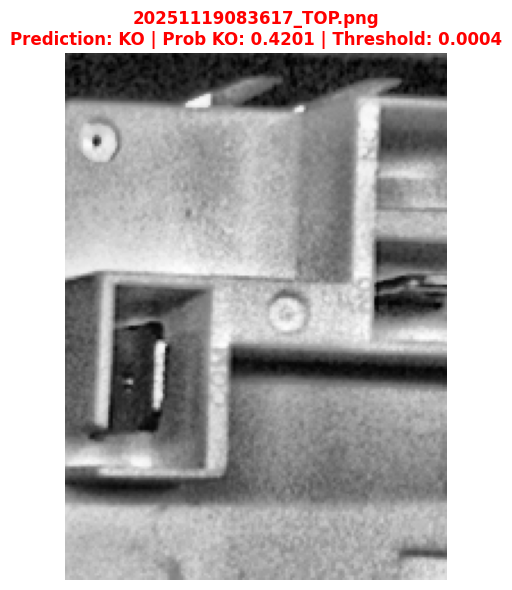


[1/7] 20251119083617_TOP.png
  Probabilità KO: 0.4201
  Soglia: 0.0004
  Predizione: KO
--------------------------------------------------------------------------------


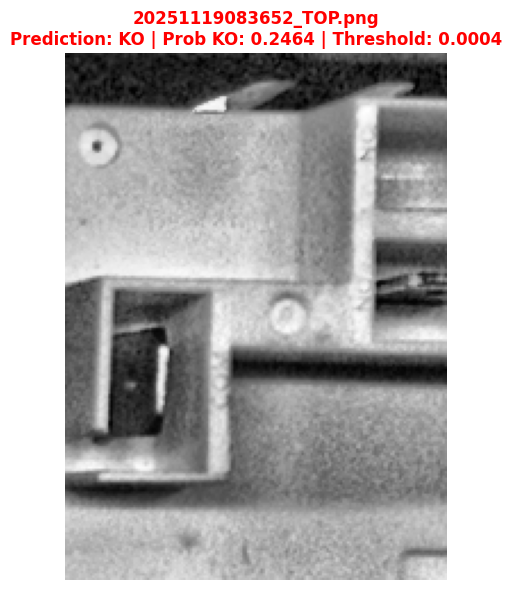


[2/7] 20251119083652_TOP.png
  Probabilità KO: 0.2464
  Soglia: 0.0004
  Predizione: KO
--------------------------------------------------------------------------------


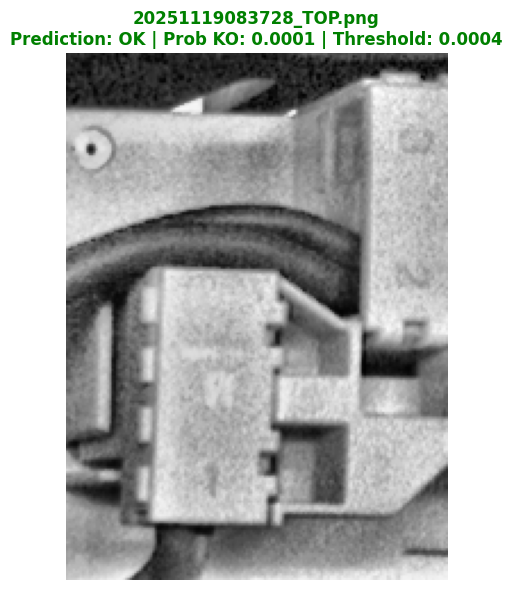


[3/7] 20251119083728_TOP.png
  Probabilità KO: 0.0001
  Soglia: 0.0004
  Predizione: OK
--------------------------------------------------------------------------------


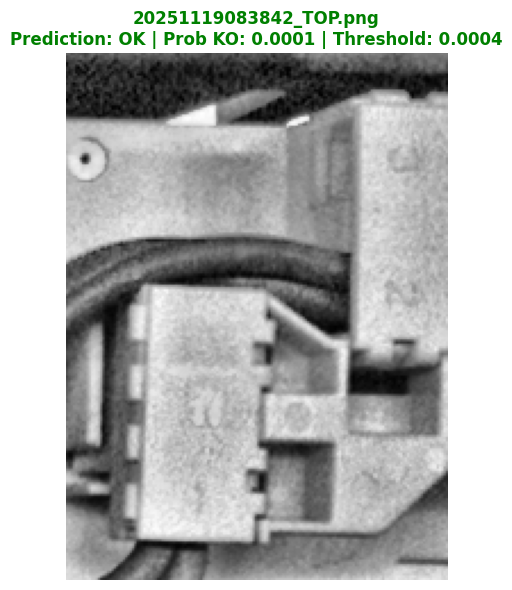


[4/7] 20251119083842_TOP.png
  Probabilità KO: 0.0001
  Soglia: 0.0004
  Predizione: OK
--------------------------------------------------------------------------------


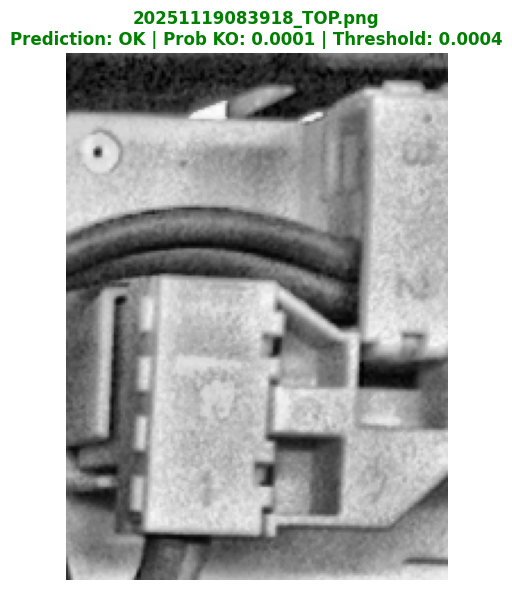


[5/7] 20251119083918_TOP.png
  Probabilità KO: 0.0001
  Soglia: 0.0004
  Predizione: OK
--------------------------------------------------------------------------------


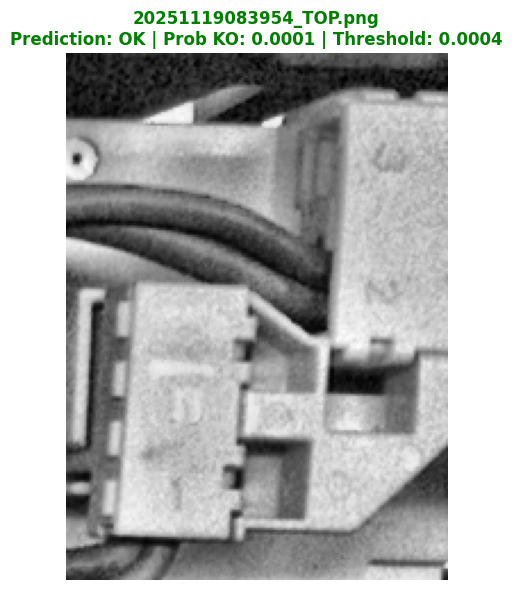


[6/7] 20251119083954_TOP.png
  Probabilità KO: 0.0001
  Soglia: 0.0004
  Predizione: OK
--------------------------------------------------------------------------------


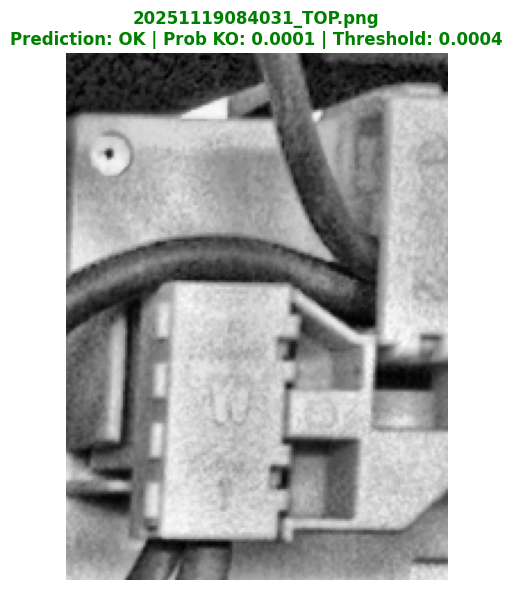


[7/7] 20251119084031_TOP.png
  Probabilità KO: 0.0001
  Soglia: 0.0004
  Predizione: OK
--------------------------------------------------------------------------------

CLASSIFICATION SUMMARY
Connector    Image                                    Prob KO      Threshold    Prediction
--------------------------------------------------------------------------------
conn5        20251119083617_TOP.png                   0.4201       0.0151       ❌ KO           
conn5        20251119083652_TOP.png                   0.2464       0.0151       ❌ KO           
conn5        20251119083728_TOP.png                   0.0001       0.0151       ✅ OK           
conn5        20251119083842_TOP.png                   0.0001       0.0151       ✅ OK           
conn5        20251119083918_TOP.png                   0.0001       0.0151       ✅ OK           
conn5        20251119083954_TOP.png                   0.0001       0.0151       ✅ OK           
conn5        20251119084031_TOP.png                   0.00

In [21]:
def load_trained_model(connector_id: str, output_root: Path, device: torch.device) -> Tuple[nn.Module, float]:
    """Load trained model and threshold for a connector."""
    model_dir = output_root / connector_id

    # Load threshold
    threshold_path = model_dir / "threshold.json"
    if not threshold_path.exists():
        raise FileNotFoundError(f"Threshold file not found for {connector_id}")

    with open(threshold_path, 'r') as f:
        threshold_data = json.load(f)
    threshold = threshold_data['threshold']

    # Load model
    model_path = model_dir / "model.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found for {connector_id}")

    model = create_model(input_channels=1, pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    return model, threshold

def classify_test_images(
    test_folder: Path,
    connector_masks: Dict,
    output_root: Path,
    device: torch.device,
    connector_id: str = "conn5"
):
    """
    Classify images from test folder using trained models.

    Assumes test images are PNG files directly in the Test folder.
    Default connector is conn1, but can be specified.
    """
    results = []

    # Get PNG images directly from Test folder
    img_files = sorted(list(test_folder.glob("*.png")))

    if not img_files:
        print(f"No PNG images found in {test_folder}")
        return results

    print(f"Found {len(img_files)} PNG images in Test folder")

    # Check if connector is available
    if connector_id not in connector_masks:
        print(f"Error: {connector_id} not found in trained models")
        print(f"Available connectors: {list(connector_masks.keys())}")
        return results

    # Load model and threshold
    try:
        model, threshold = load_trained_model(connector_id, output_root, device)
        print(f"\nLoaded model for {connector_id}, threshold: {threshold:.4f}")
    except Exception as e:
        print(f"Error loading model for {connector_id}: {e}")
        return results

    # Classify images
    print(f"\nClassifying {len(img_files)} images as {connector_id}...")
    print("="*80)

    for idx, img_path in enumerate(img_files):
        try:
            prob_ko, is_ko = predict_connector(
                img_path, connector_id, model, connector_masks[connector_id], threshold, device
            )
            prediction = 'KO' if is_ko else 'OK'

            results.append({
                'connector': connector_id,
                'image': img_path.name,
                'path': str(img_path),
                'prob_ko': prob_ko,
                'is_ko': is_ko,
                'prediction': prediction
            })

            # Visualize result
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                img = np.array(Image.open(img_path).convert('L'))

            # Create visualization
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            ax.imshow(img, cmap='gray')

            # Color based on prediction
            color = 'red' if is_ko else 'green'
            title = f"{img_path.name}\nPrediction: {prediction} | Prob KO: {prob_ko:.4f} | Threshold: {threshold:.4f}"
            ax.set_title(title, fontsize=12, color=color, weight='bold')
            ax.axis('off')

            # Add border based on prediction
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

            plt.tight_layout()
            plt.show()

            print(f"\n[{idx+1}/{len(img_files)}] {img_path.name}")
            print(f"  Probabilità KO: {prob_ko:.4f}")
            print(f"  Soglia: {threshold:.4f}")
            print(f"  Predizione: {prediction}")
            print("-"*80)

        except Exception as e:
            print(f"\nError processing {img_path.name}: {e}")
            import traceback
            traceback.print_exc()
            results.append({
                'connector': connector_id,
                'image': img_path.name,
                'path': str(img_path),
                'prob_ko': None,
                'is_ko': None,
                'prediction': f'ERROR: {str(e)}'
            })
            print("-"*80)

    return results

# Test folder path (in Colab current directory)
TEST_FOLDER = Path("./test2")

if not TEST_FOLDER.exists():
    print(f"Warning: Test folder not found at {TEST_FOLDER}")
    print("Please ensure the test2 folder exists in the current Colab directory")
    print("Expected structure: test2/ contains PNG images of conn2")
else:
    print(f"Classifying images from: {TEST_FOLDER}")
    print("="*80)

    # Classify images as conn2
    test_results = classify_test_images(
        TEST_FOLDER,
        connector_masks,
        OUTPUT_ROOT,
        device,
        connector_id="conn5"
    )

    # Print detailed summary
    print("\n" + "="*80)
    print("CLASSIFICATION SUMMARY")
    print("="*80)
    print(f"{'Connector':<12} {'Image':<40} {'Prob KO':<12} {'Threshold':<12} {'Prediction':<10}")
    print("-"*80)

    ok_count = 0
    ko_count = 0
    error_count = 0

    # Load threshold for display
    try:
        threshold_path = OUTPUT_ROOT / connector_id / "threshold.json"
        with open(threshold_path, 'r') as f:
            threshold_data = json.load(f)
        threshold_val = threshold_data['threshold']
    except:
        threshold_val = None

    for result in test_results:
        prob_str = f"{result['prob_ko']:.4f}" if result['prob_ko'] is not None else "N/A"
        threshold_str = f"{threshold_val:.4f}" if threshold_val is not None else "N/A"
        pred = result['prediction']

        if 'ERROR' in pred:
            error_count += 1
        elif pred == 'KO':
            ko_count += 1
        else:
            ok_count += 1

        # Color coding in print (if terminal supports it)
        pred_display = pred
        if pred == 'KO':
            pred_display = f"❌ {pred}"
        elif pred == 'OK':
            pred_display = f"✅ {pred}"

        print(f"{result['connector']:<12} {result['image']:<40} {prob_str:<12} {threshold_str:<12} {pred_display:<15}")

    print("-"*80)
    print(f"\n📊 STATISTICS:")
    print(f"  Total images processed: {len(test_results)}")
    print(f"  ✅ OK: {ok_count}")
    print(f"  ❌ KO: {ko_count}")
    print(f"  ⚠️  Errors: {error_count}")
    print("="*80)

    # Save results to CSV
    if test_results:
        import pandas as pd
        df_results = pd.DataFrame(test_results)
        results_csv_path = OUTPUT_ROOT / "test_classification_results.csv"
        df_results.to_csv(results_csv_path, index=False)
        print(f"\nResults saved to: {results_csv_path}")


## Advanced Visualization & Analysis Cells

These cells provide detailed analysis and visualizations for trained models.
Run these cells AFTER training is complete.

Analyzing: 20251106111316_TOP.png


/tmp/ipython-input-3993809027.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


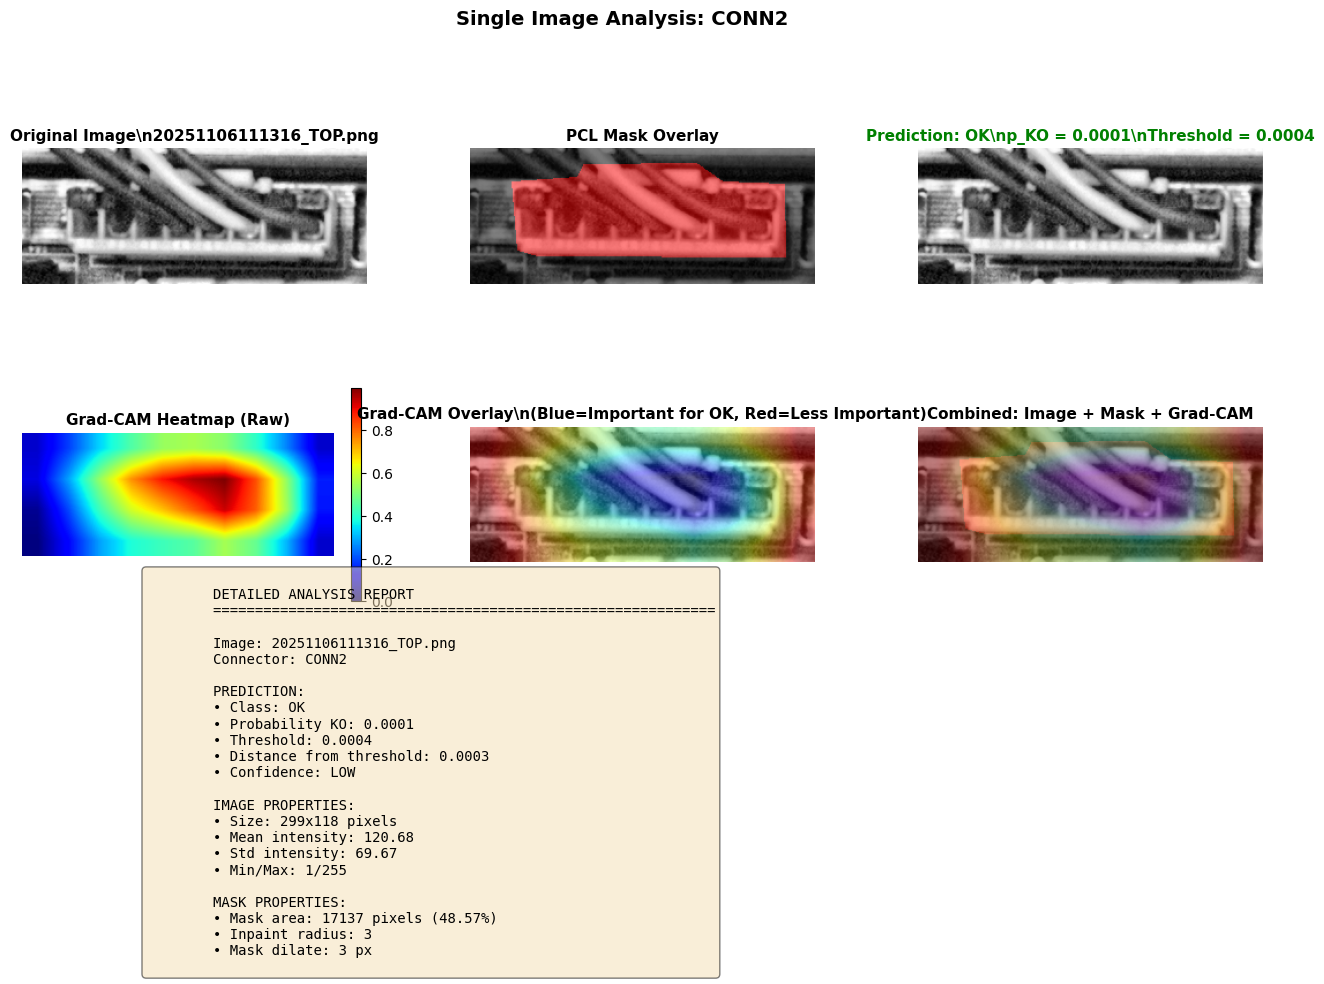

In [68]:
# CELL G — Detailed Single Image Analysis with Grad-CAM
# Analyze a single image with comprehensive visualizations

from matplotlib.gridspec import GridSpec  # Import GridSpec for layout

connector_id = "conn2"  # Change this
image_path = None  # Set to specific image path, or None to pick random

try:
    # Load model and threshold
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get image (from Data with KO folder for analysis)
    conn_dir = CONNECTORS_WITH_KO_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    if image_path is None:
        # Pick random image
        import random
        image_path = random.choice(img_files)

    image_path = Path(image_path)

    if not image_path.exists():
        print(f"Image not found: {image_path}")
    else:
        print(f"Analyzing: {image_path.name}")

        # Load and preprocess image
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(image_path).convert('L'))

        # Get prediction
        prob_ko, is_ko = predict_connector(image_path, connector_id, model, info, threshold, device)
        prediction = "KO" if is_ko else "OK"

        # Generate Grad-CAM
        def generate_gradcam_detailed(model, image_tensor, target_layer, device, is_ko_prediction):
            """
            Generate detailed Grad-CAM heatmap.

            For OK images (is_ko_prediction=False): backward on (1 - prob_ko) to see what keeps KO prob low
            For KO images (is_ko_prediction=True): backward on prob_ko to see what increases KO prob
            """
            model.eval()

            gradients = []
            activations = []

            def backward_hook(module, grad_input, grad_output):
                if grad_output[0] is not None:
                    gradients.append(grad_output[0].detach())  # Detach gradients

            def forward_hook(module, input, output):
                activations.append(output.detach())  # Detach activations

            # Use register_full_backward_hook to avoid deprecation warning
            try:
                hook_handle = target_layer.register_full_backward_hook(backward_hook)
            except:
                hook_handle = target_layer.register_backward_hook(backward_hook)

            forward_handle = target_layer.register_forward_hook(forward_hook)

            # Forward pass
            output = model(image_tensor)
            prob_ko = torch.sigmoid(output).item()

            # Backward pass - CRITICAL: direction depends on prediction
            model.zero_grad()

            if is_ko_prediction:
                # For KO: backward on prob_ko (what increases KO probability)
                # Use positive gradient
                prob_tensor = torch.sigmoid(output)
                prob_tensor.backward()
            else:
                # For OK: backward on (1 - prob_ko) (what keeps KO probability low)
                # Use negative gradient to see what contributes to LOW prob_ko
                prob_tensor = torch.sigmoid(output)
                prob_ok_tensor = 1.0 - prob_tensor
                prob_ok_tensor.backward()

            # Get gradients and activations
            if len(gradients) == 0 or len(activations) == 0:
                hook_handle.remove()
                forward_handle.remove()
                return None, prob_ko

            grads = gradients[0]
            acts = activations[0]

            # Global average pooling of gradients
            weights = torch.mean(grads, dim=(2, 3), keepdim=True)

            # Weighted combination
            cam = torch.sum(weights * acts, dim=1, keepdim=True)

            # For OK images, we want to see positive contributions (what helps keep prob_ko low)
            # For KO images, we want to see positive contributions (what increases prob_ko)
            # Apply ReLU to get positive contributions
            cam = torch.relu(cam)

            # Normalize - IMPORTANT: detach before converting to numpy
            cam = cam.squeeze().detach().cpu().numpy()
            if cam.max() > cam.min():
                cam = (cam - cam.min()) / (cam.max() - cam.min())
            else:
                cam = np.zeros_like(cam)

            # Resize to input size
            h, w = image_tensor.shape[2], image_tensor.shape[3]
            cam_resized = cv2.resize(cam, (w, h))

            hook_handle.remove()
            forward_handle.remove()

            return cam_resized, prob_ko

        # Preprocess for model
        img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(device)

        # Get target layer
        target_layer = model.backbone.layer4

        # Generate Grad-CAM - pass is_ko_prediction to determine backward direction
        heatmap, prob_pred = generate_gradcam_detailed(model, img_tensor, target_layer, device, is_ko_prediction=is_ko)

        # Create comprehensive visualization
        fig = plt.figure(figsize=(16, 10))
        gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

        # Original image
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(img, cmap='gray')
        ax1.set_title(f"Original Image\\n{image_path.name}", fontsize=11, weight='bold')
        ax1.axis('off')

        # Mask overlay
        ax2 = fig.add_subplot(gs[0, 1])
        overlay = overlay_mask_on_image(img, info['mask'], alpha=0.5)
        ax2.imshow(overlay)
        ax2.set_title("PCL Mask Overlay", fontsize=11, weight='bold')
        ax2.axis('off')

        # Prediction with border
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.imshow(img, cmap='gray')
        color = 'red' if is_ko else 'green'
        for spine in ax3.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)
        ax3.set_title(f"Prediction: {prediction}\\np_KO = {prob_ko:.4f}\\nThreshold = {threshold:.4f}",
                     fontsize=11, weight='bold', color=color)
        ax3.axis('off')

        # Grad-CAM heatmap (raw)
        ax4 = fig.add_subplot(gs[1, 0])
        if heatmap is not None:
            im = ax4.imshow(heatmap, cmap='jet', interpolation='bilinear')
            ax4.set_title("Grad-CAM Heatmap (Raw)", fontsize=11, weight='bold')
            ax4.axis('off')
            plt.colorbar(im, ax=ax4, fraction=0.046)
        else:
            ax4.text(0.5, 0.5, "Grad-CAM failed", ha='center', va='center')
            ax4.axis('off')

        # Grad-CAM overlay
        ax5 = fig.add_subplot(gs[1, 1])
        if heatmap is not None:
            # For OK: heatmap shows what contributes to LOW prob_ko (blue = important for OK)
            # For KO: heatmap shows what contributes to HIGH prob_ko (red = important for KO)
            if is_ko:
                # KO: red = important for KO prediction
                heatmap_colored = plt.cm.jet(heatmap)[:, :, :3]
                title_text = "Grad-CAM Overlay\\n(Red=Important for KO)"
            else:
                # OK: invert to show what helps keep prob_ko LOW (blue = important for OK)
                heatmap_inv = 1.0 - heatmap
                heatmap_colored = plt.cm.jet(heatmap_inv)[:, :, :3]
                title_text = "Grad-CAM Overlay\\n(Blue=Important for OK, Red=Less Important)"

            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
            overlay_cam = 0.6 * img_rgb + 0.4 * heatmap_colored
            ax5.imshow(overlay_cam)
            ax5.set_title(title_text, fontsize=11, weight='bold')
            ax5.axis('off')
        else:
            ax5.text(0.5, 0.5, "Grad-CAM failed", ha='center', va='center')
            ax5.axis('off')

        # Combined: Image + Mask + Grad-CAM
        ax6 = fig.add_subplot(gs[1, 2])
        if heatmap is not None:
            # Combine all visualizations
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
            mask_overlay = np.zeros_like(img_rgb)
            mask_overlay[info['mask'] > 0] = [1, 0, 0]  # Red mask for PCL region

            # Use same colormap logic as overlay
            if is_ko:
                heatmap_overlay = plt.cm.jet(heatmap)[:, :, :3]
            else:
                heatmap_overlay = plt.cm.jet(1.0 - heatmap)[:, :, :3]

            combined = 0.5 * img_rgb + 0.2 * mask_overlay + 0.3 * heatmap_overlay
            ax6.imshow(combined)
            ax6.set_title("Combined: Image + Mask + Grad-CAM", fontsize=11, weight='bold')
            ax6.axis('off')
        else:
            ax6.text(0.5, 0.5, "Grad-CAM failed", ha='center', va='center')
            ax6.axis('off')

        # Statistics panel
        ax7 = fig.add_subplot(gs[2, :])
        ax7.axis('off')

        stats_text = f"""
        DETAILED ANALYSIS REPORT
        {'='*60}

        Image: {image_path.name}
        Connector: {connector_id.upper()}

        PREDICTION:
        • Class: {prediction}
        • Probability KO: {prob_ko:.4f}
        • Threshold: {threshold:.4f}
        • Distance from threshold: {abs(prob_ko - threshold):.4f}
        • Confidence: {'HIGH' if abs(prob_ko - threshold) > 0.1 else 'MEDIUM' if abs(prob_ko - threshold) > 0.05 else 'LOW'}

        IMAGE PROPERTIES:
        • Size: {img.shape[1]}x{img.shape[0]} pixels
        • Mean intensity: {np.mean(img):.2f}
        • Std intensity: {np.std(img):.2f}
        • Min/Max: {np.min(img)}/{np.max(img)}

        MASK PROPERTIES:
        • Mask area: {np.sum(info['mask'] > 0)} pixels ({np.sum(info['mask'] > 0) / info['mask'].size * 100:.2f}%)
        • Inpaint radius: {info['inpaint_radius']}
        • Mask dilate: {info['mask_dilate_px']} px
        """

        ax7.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.suptitle(f"Single Image Analysis: {connector_id.upper()}",
                    fontsize=14, weight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Using all connector images: 317 images
\nLoading ground truth labels from CSV...
CSV loaded: 2853 rows
Found 317 OK/KO labels for conn2
✅ Matched 317/317 images with ground truth
\nComputing predictions for 317 images...


100%|██████████| 317/317 [00:07<00:00, 45.19it/s]


\nGround Truth Distribution:
  OK samples: 312
  KO samples: 5
\n============================================================
PERFORMANCE METRICS (with Ground Truth)
Threshold: 0.0004
Total matched images: 317
\nConfusion Matrix:
  True Negatives (TN):  311
  False Positives (FP): 1
  False Negatives (FN): 0
  True Positives (TP):  5
\nPrecision: 0.8333
Recall: 1.0000
Specificity: 0.9968
Accuracy: 0.9968
\nROC AUC: 1.0000


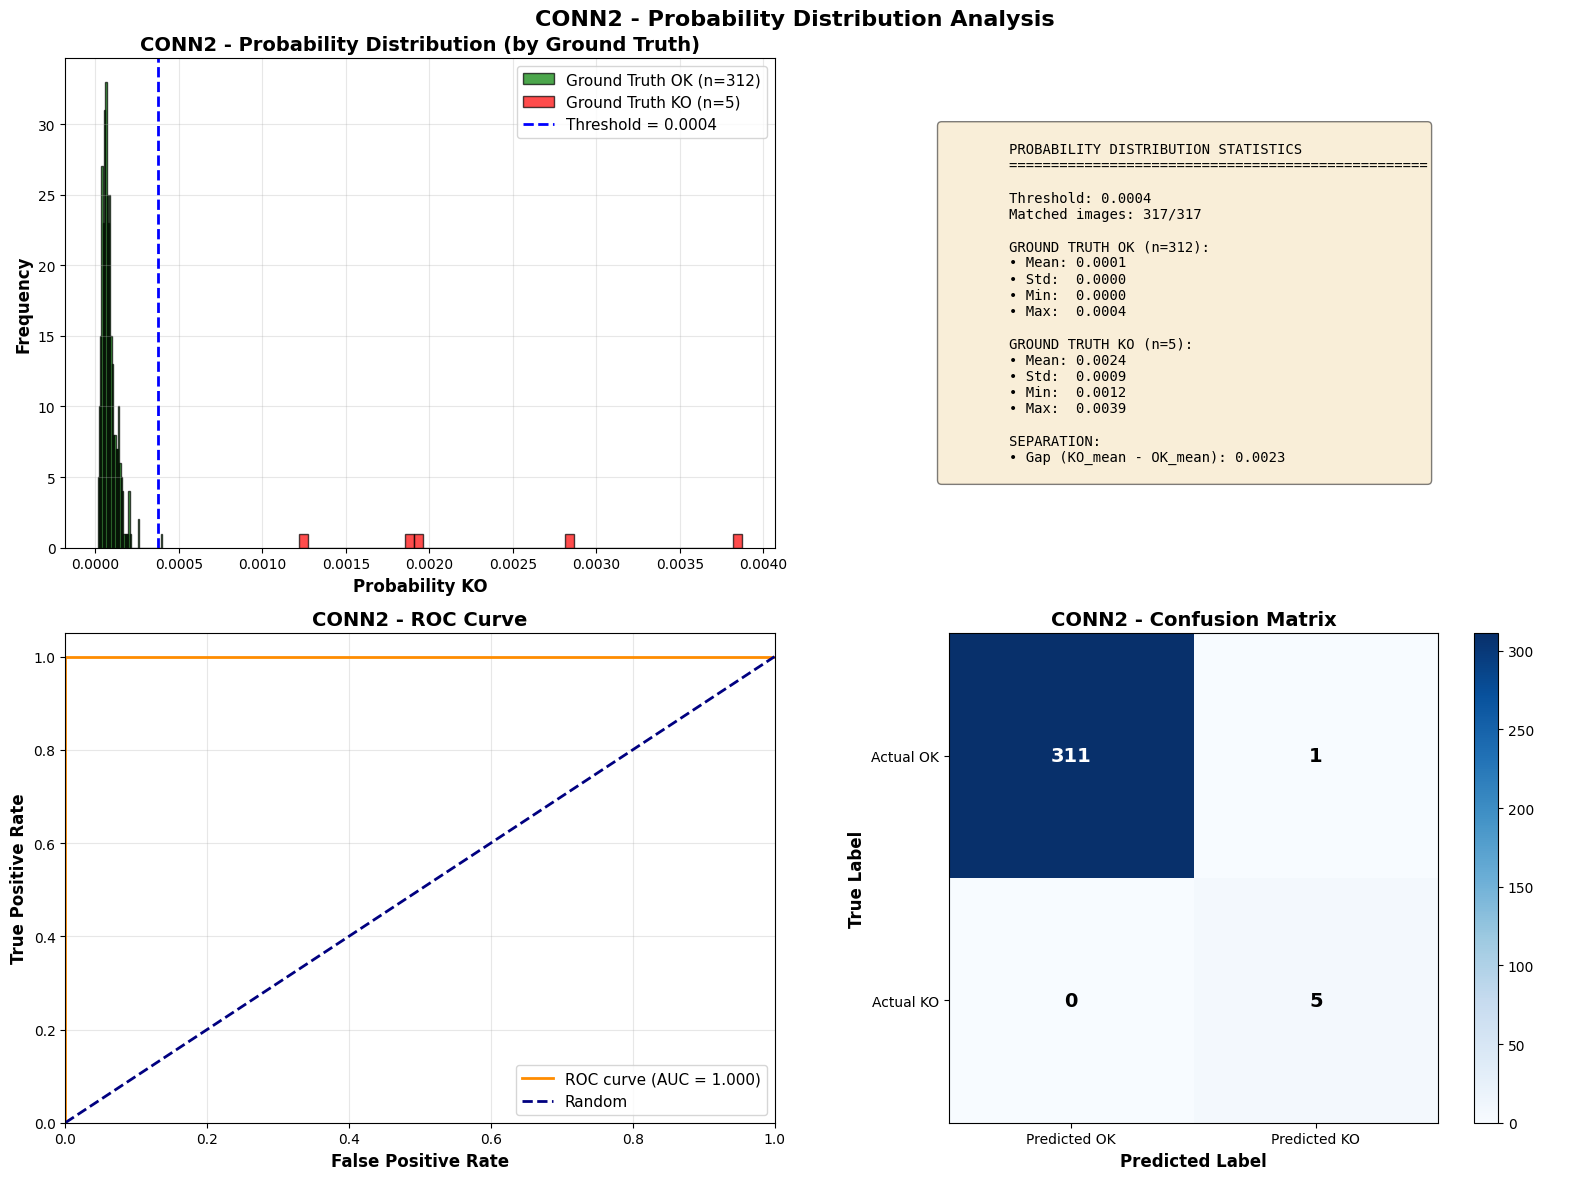

\n============================================================
FALSE POSITIVES: 1 OK images predicted as KO
These are OK images with prob_ko >= threshold (0.0004)
\nShowing up to 12 false positives...


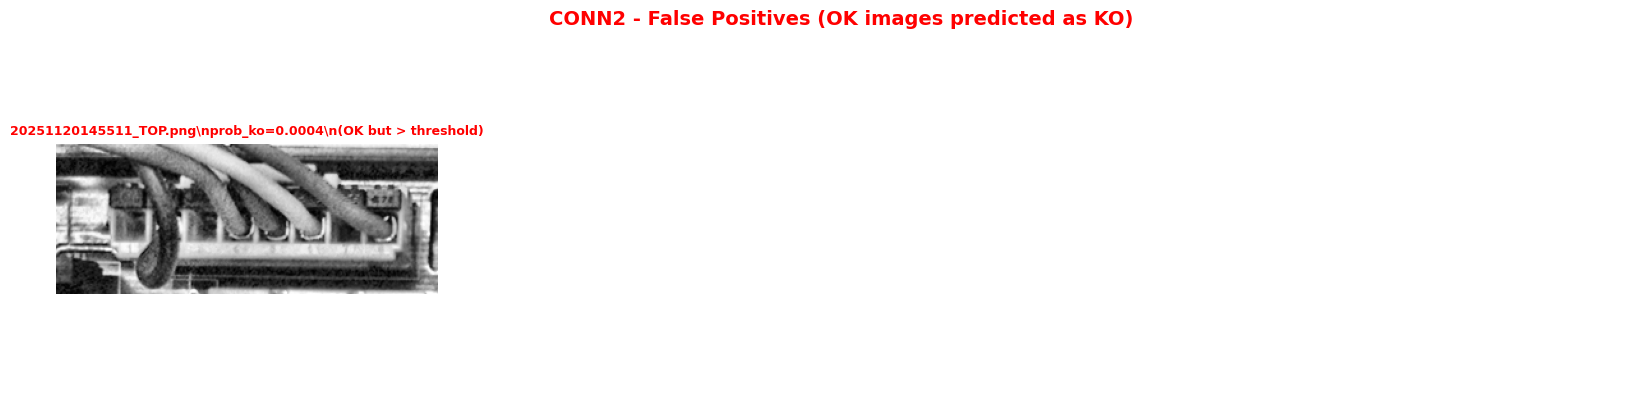

\nFalse Positive Summary:
  Total False Positives: 1
  Min prob_ko: 0.0004
  Max prob_ko: 0.0004
  Mean prob_ko: 0.0004
  Threshold: 0.0004


In [83]:
# CELL H — Probability Distribution Analysis with Ground Truth
# Analyze probability distributions and compute ROC curve/confusion matrix
# Requires features_labeled.csv with columns: filename, connector_name, label

connector_id = "conn2"  # Change this
use_test_folder = False  # If True, uses Test/ folder; if False, uses all connector images
csv_path = BASE_DIR / "features_labeled.csv"  # Path to labeled CSV (upload to Colab)

try:
    from sklearn.metrics import roc_curve, auc, confusion_matrix
    import pandas as pd

    # Load model and threshold
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get image (from Data with KO folder for analysis)
    conn_dir = CONNECTORS_WITH_KO_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    # Optionally use Test folder
    test_folder = conn_dir / "Test"
    if use_test_folder and test_folder.exists():
        test_images = sorted(list(test_folder.glob("*.png")) + list(test_folder.glob("*.jpg")))
        if test_images:
            img_files = test_images
            print(f"Using Test folder: {len(img_files)} images")
        else:
            print("Test folder empty, using all connector images")
    else:
        print(f"Using all connector images: {len(img_files)} images")

    if len(img_files) == 0:
        print("No images found!")
    else:
        # Load ground truth labels from CSV
        print(f"\\nLoading ground truth labels from CSV...")
        has_ground_truth = False
        gt_labels_list = []

        if csv_path.exists():
            try:
                df_gt = pd.read_csv(csv_path)
                print(f"CSV loaded: {len(df_gt)} rows")

                # Filter for current connector and only OK/KO (exclude OCCLUSION)
                df_conn = df_gt[
                    (df_gt['connector_name'] == connector_id) &
                    (df_gt['label'].isin(['OK', 'KO']))
                ].copy()
                print(f"Found {len(df_conn)} OK/KO labels for {connector_id}")

                # Create mapping: filename -> label
                # Crop filenames match CSV filenames exactly (e.g., "20251106110559_TOP.png")
                filename_to_label = {}
                for _, row in df_conn.iterrows():
                    csv_filename = row['filename']  # e.g., "20251106110559_TOP.png"
                    label = row['label']
                    filename_to_label[csv_filename] = label

                # Match images with ground truth
                matched_count = 0
                for img_path in img_files:
                    img_filename = img_path.name  # e.g., "20251106110559_TOP.png"

                    if img_filename in filename_to_label:
                        label = filename_to_label[img_filename]
                        # Convert to binary: KO=1, OK=0
                        gt_labels_list.append(1 if label == 'KO' else 0)
                        matched_count += 1
                    else:
                        gt_labels_list.append(None)  # No match found

                if matched_count > 0:
                    has_ground_truth = True
                    print(f"✅ Matched {matched_count}/{len(img_files)} images with ground truth")
                else:
                    print(f"⚠️  No matches found between images and CSV labels")
                    print(f"   Sample CSV filename: {df_conn.iloc[0]['filename'] if len(df_conn) > 0 else 'N/A'}")
                    print(f"   Sample image filename: {img_files[0].name if len(img_files) > 0 else 'N/A'}")
            except Exception as e:
                print(f"⚠️  Error loading ground truth: {e}")
                import traceback
                traceback.print_exc()
        else:
            print(f"⚠️  CSV not found at {csv_path}")
            print(f"   Upload features_labeled.csv to Colab in the same directory as the notebook")

        # Compute predictions
        print(f"\\nComputing predictions for {len(img_files)} images...")
        all_probs = []
        all_predictions = []

        for img_path in tqdm(img_files):
            prob_ko, is_ko = predict_connector(
                img_path, connector_id, model, info, threshold, device
            )
            all_probs.append(prob_ko)
            all_predictions.append(1 if is_ko else 0)  # 1 = KO, 0 = OK

        all_probs = np.array(all_probs)
        all_predictions = np.array(all_predictions)

        # Separate OK and KO predictions
        ok_probs = all_probs[all_predictions == 0]
        ko_probs = all_probs[all_predictions == 1]

        # Filter to only images with ground truth labels
        if has_ground_truth:
            gt_labels_array = np.array(gt_labels_list)
            valid_mask = np.array([l is not None for l in gt_labels_list])
            valid_probs = all_probs[valid_mask]
            valid_gt = gt_labels_array[valid_mask].astype(int)
            valid_predictions = all_predictions[valid_mask]

            # Separate by ground truth (not predictions!)
            gt_ok_probs = valid_probs[valid_gt == 0]
            gt_ko_probs = valid_probs[valid_gt == 1]

            print(f"\\nGround Truth Distribution:")
            print(f"  OK samples: {len(gt_ok_probs)}")
            print(f"  KO samples: {len(gt_ko_probs)}")

            # Check if both classes are present
            has_both_classes = len(np.unique(valid_gt)) == 2
        else:
            valid_probs = all_probs
            valid_gt = None
            valid_predictions = all_predictions
            gt_ok_probs = ok_probs
            gt_ko_probs = ko_probs
            has_both_classes = False

        # Create visualization
        # Use 2x2 layout only if we have ground truth AND both classes (OK and KO)
        if has_ground_truth and has_both_classes:
            fig, axes_2d = plt.subplots(2, 2, figsize=(16, 12))
            axes = [axes_2d[0, 0], axes_2d[0, 1], axes_2d[1, 0], axes_2d[1, 1]]
        else:
            # Use 1x2 layout for other cases
            fig, axes_1d = plt.subplots(1, 2, figsize=(14, 6))
            axes = [axes_1d[0], axes_1d[1], None, None]

        # Plot 1: Probability Distribution (by Ground Truth if available, else by Prediction)
        ax1 = axes[0]
        if has_ground_truth:
            if len(gt_ok_probs) > 0:
                ax1.hist(gt_ok_probs, bins=50, alpha=0.7, label=f'Ground Truth OK (n={len(gt_ok_probs)})',
                        color='green', edgecolor='black')
            if len(gt_ko_probs) > 0:
                ax1.hist(gt_ko_probs, bins=50, alpha=0.7, label=f'Ground Truth KO (n={len(gt_ko_probs)})',
                        color='red', edgecolor='black')
            title_suffix = " (by Ground Truth)"
        else:
            if len(ok_probs) > 0:
                ax1.hist(ok_probs, bins=50, alpha=0.7, label=f'Predicted OK (n={len(ok_probs)})',
                        color='green', edgecolor='black')
            if len(ko_probs) > 0:
                ax1.hist(ko_probs, bins=50, alpha=0.7, label=f'Predicted KO (n={len(ko_probs)})',
                        color='red', edgecolor='black')
            title_suffix = " (by Prediction)"

        ax1.axvline(threshold, color='blue', linestyle='--', linewidth=2,
                   label=f'Threshold = {threshold:.4f}')
        ax1.set_xlabel('Probability KO', fontsize=12, weight='bold')
        ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
        ax1.set_title(f'{connector_id.upper()} - Probability Distribution{title_suffix}',
                     fontsize=14, weight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Statistics Summary
        ax2 = axes[1]
        ax2.axis('off')

        # Calculate statistics
        if has_ground_truth:
            ok_mean = np.mean(gt_ok_probs) if len(gt_ok_probs) > 0 else 0.0
            ok_std = np.std(gt_ok_probs) if len(gt_ok_probs) > 0 else 0.0
            ok_min = np.min(gt_ok_probs) if len(gt_ok_probs) > 0 else 0.0
            ok_max = np.max(gt_ok_probs) if len(gt_ok_probs) > 0 else 0.0
            ok_n = len(gt_ok_probs)

            ko_mean = np.mean(gt_ko_probs) if len(gt_ko_probs) > 0 else 0.0
            ko_std = np.std(gt_ko_probs) if len(gt_ko_probs) > 0 else 0.0
            ko_min = np.min(gt_ko_probs) if len(gt_ko_probs) > 0 else 0.0
            ko_max = np.max(gt_ko_probs) if len(gt_ko_probs) > 0 else 0.0
            ko_n = len(gt_ko_probs)

            gap = ko_mean - ok_mean

            stats_text = f"""
        PROBABILITY DISTRIBUTION STATISTICS
        {'='*50}

        Threshold: {threshold:.4f}
        Matched images: {matched_count}/{len(img_files)}

        GROUND TRUTH OK (n={ok_n}):
        • Mean: {ok_mean:.4f}
        • Std:  {ok_std:.4f}
        • Min:  {ok_min:.4f}
        • Max:  {ok_max:.4f}

        GROUND TRUTH KO (n={ko_n}):
        • Mean: {ko_mean:.4f}
        • Std:  {ko_std:.4f}
        • Min:  {ko_min:.4f}
        • Max:  {ko_max:.4f}

        SEPARATION:
        • Gap (KO_mean - OK_mean): {gap:.4f}
        """
        else:
            ok_mean = np.mean(ok_probs) if len(ok_probs) > 0 else 0.0
            ok_std = np.std(ok_probs) if len(ok_probs) > 0 else 0.0
            ok_min = np.min(ok_probs) if len(ok_probs) > 0 else 0.0
            ok_max = np.max(ok_probs) if len(ok_probs) > 0 else 0.0
            ok_below = np.sum(ok_probs < threshold) if len(ok_probs) > 0 else 0
            ok_above = np.sum(ok_probs >= threshold) if len(ok_probs) > 0 else 0
            ok_below_pct = (ok_below / len(ok_probs) * 100) if len(ok_probs) > 0 else 0.0
            ok_above_pct = (ok_above / len(ok_probs) * 100) if len(ok_probs) > 0 else 0.0

            ko_mean = np.mean(ko_probs) if len(ko_probs) > 0 else 0.0
            ko_std = np.std(ko_probs) if len(ko_probs) > 0 else 0.0
            ko_min = np.min(ko_probs) if len(ko_probs) > 0 else 0.0
            ko_max = np.max(ko_probs) if len(ko_probs) > 0 else 0.0
            gap = ko_mean - ok_mean

            stats_text = f"""
        PROBABILITY DISTRIBUTION STATISTICS
        {'='*50}

        Threshold: {threshold:.4f}

        PREDICTED OK (n={len(ok_probs)}):
        • Mean: {ok_mean:.4f}
        • Std:  {ok_std:.4f}
        • Min:  {ok_min:.4f}
        • Max:  {ok_max:.4f}
        • Below threshold: {ok_below} ({ok_below_pct:.1f}%)
        • Above threshold: {ok_above} ({ok_above_pct:.1f}%)

        PREDICTED KO (n={len(ko_probs)}):
        • Mean: {ko_mean:.4f}
        • Std:  {ko_std:.4f}
        • Min:  {ko_min:.4f}
        • Max:  {ko_max:.4f}

        SEPARATION:
        • Gap (KO_mean - OK_mean): {gap:.4f}

        ⚠️  NOTE: No ground truth labels available.
        Upload features_labeled.csv to enable ROC curve and confusion matrix.
        """

        ax2.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # Plot 3: ROC Curve (only if ground truth available and both classes present)
        if has_ground_truth and has_both_classes and axes[2] is not None:
            ax3 = axes[2]
            fpr, tpr, roc_thresholds = roc_curve(valid_gt, valid_probs)
            roc_auc = auc(fpr, tpr)

            ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
            ax3.set_xlim([0.0, 1.0])
            ax3.set_ylim([0.0, 1.05])
            ax3.set_xlabel('False Positive Rate', fontsize=12, weight='bold')
            ax3.set_ylabel('True Positive Rate', fontsize=12, weight='bold')
            ax3.set_title(f'{connector_id.upper()} - ROC Curve', fontsize=14, weight='bold')
            ax3.legend(loc="lower right", fontsize=11)
            ax3.grid(True, alpha=0.3)

            # Plot 4: Confusion Matrix
            ax4 = axes[3]
            cm = confusion_matrix(valid_gt, (valid_probs >= threshold).astype(int))
            tn, fp, fn, tp = cm.ravel()

            im = ax4.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax4.figure.colorbar(im, ax=ax4)

            # Add text annotations
            thresh = cm.max() / 2.
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax4.text(j, i, format(cm[i, j], 'd'),
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black",
                            fontsize=14, weight='bold')

            ax4.set_xticks([0, 1])
            ax4.set_yticks([0, 1])
            ax4.set_xticklabels(['Predicted OK', 'Predicted KO'])
            ax4.set_yticklabels(['Actual OK', 'Actual KO'])
            ax4.set_ylabel('True Label', fontsize=12, weight='bold')
            ax4.set_xlabel('Predicted Label', fontsize=12, weight='bold')
            ax4.set_title(f'{connector_id.upper()} - Confusion Matrix', fontsize=14, weight='bold')

            # Print metrics
            print("\\n" + "="*60)
            print("PERFORMANCE METRICS (with Ground Truth)")
            print("="*60)
            print(f"Threshold: {threshold:.4f}")
            print(f"Total matched images: {matched_count}")
            print(f"\\nConfusion Matrix:")
            print(f"  True Negatives (TN):  {tn}")
            print(f"  False Positives (FP): {fp}")
            print(f"  False Negatives (FN): {fn}")
            print(f"  True Positives (TP):  {tp}")

            if (tp + fp) > 0:
                precision = tp / (tp + fp)
                print(f"\\nPrecision: {precision:.4f}")

            if (tp + fn) > 0:
                recall = tp / (tp + fn)
                print(f"Recall: {recall:.4f}")

            if (tn + fp) > 0:
                specificity = tn / (tn + fp)
                print(f"Specificity: {specificity:.4f}")

            if (tn + fp + fn + tp) > 0:
                accuracy = (tn + tp) / (tn + fp + fn + tp)
                print(f"Accuracy: {accuracy:.4f}")

            print(f"\\nROC AUC: {roc_auc:.4f}")
            print("="*60)
        elif has_ground_truth and not has_both_classes:
            # Print warning if only one class is present
            print("\\n" + "="*60)
            print("⚠️  WARNING: Only one class present in ground truth labels")
            print("="*60)
            print(f"Ground Truth Distribution:")
            print(f"  OK samples: {len(gt_ok_probs)}")
            print(f"  KO samples: {len(gt_ko_probs)}")
            print(f"\\nROC curve and confusion matrix require both OK and KO samples.")
            print(f"Only probability distribution and statistics are shown.")
            print("="*60)

        plt.suptitle(f'{connector_id.upper()} - Probability Distribution Analysis',
                    fontsize=16, weight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

        # Show False Positives: OK images predicted as KO (above threshold)
        if has_ground_truth:
            # Find OK images with prob_ko >= threshold (False Positives)
            false_positive_probs = []
            false_positive_paths = []

            for img_path, prob, gt_label in zip(img_files, all_probs, gt_labels_list):
                if gt_label is not None and gt_label == 0:  # Ground truth OK
                    if prob >= threshold:  # Predicted as KO
                        false_positive_probs.append(prob)
                        false_positive_paths.append(img_path)

            if len(false_positive_paths) > 0:
                print(f"\\n" + "="*60)
                print(f"FALSE POSITIVES: {len(false_positive_paths)} OK images predicted as KO")
                print("="*60)
                print(f"These are OK images with prob_ko >= threshold ({threshold:.4f})")
                print(f"\\nShowing up to 12 false positives...")

                # Show up to 12 false positives in a grid
                n_to_show = min(12, len(false_positive_paths))
                n_cols = 4
                n_rows = (n_to_show + n_cols - 1) // n_cols

                fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
                if n_rows == 1:
                    axes = axes.reshape(1, -1)
                axes = axes.flatten()

                for idx in range(n_to_show):
                    img_path = false_positive_paths[idx]
                    prob_ko = false_positive_probs[idx]

                    # Load image
                    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        img = np.array(Image.open(img_path).convert('L'))

                    # Display with red border to indicate false positive
                    axes[idx].imshow(img, cmap='gray')
                    axes[idx].set_title(f"{img_path.name}\\nprob_ko={prob_ko:.4f}\\n(OK but > threshold)",
                                       fontsize=9, color='red', weight='bold')
                    axes[idx].axis('off')

                    # Add red border
                    for spine in axes[idx].spines.values():
                        spine.set_edgecolor('red')
                        spine.set_linewidth(3)

                # Hide unused subplots
                for idx in range(n_to_show, len(axes)):
                    axes[idx].axis('off')

                plt.suptitle(f'{connector_id.upper()} - False Positives (OK images predicted as KO)',
                           fontsize=14, weight='bold', color='red')
                plt.tight_layout()
                plt.show()

                # Print summary
                print(f"\\nFalse Positive Summary:")
                print(f"  Total False Positives: {len(false_positive_paths)}")
                if len(false_positive_probs) > 0:
                    print(f"  Min prob_ko: {np.min(false_positive_probs):.4f}")
                    print(f"  Max prob_ko: {np.max(false_positive_probs):.4f}")
                    print(f"  Mean prob_ko: {np.mean(false_positive_probs):.4f}")
                print(f"  Threshold: {threshold:.4f}")
            else:
                print(f"\\n✅ No false positives found!")
                print(f"   All OK images have prob_ko < threshold ({threshold:.4f})")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Found 9 trained connectors: ['conn1', 'conn2', 'conn3', 'conn4', 'conn5', 'conn6', 'conn7', 'conn8', 'conn9']


Processing conn9: 100%|██████████| 100/100 [00:00<00:00, 100.29it/s]


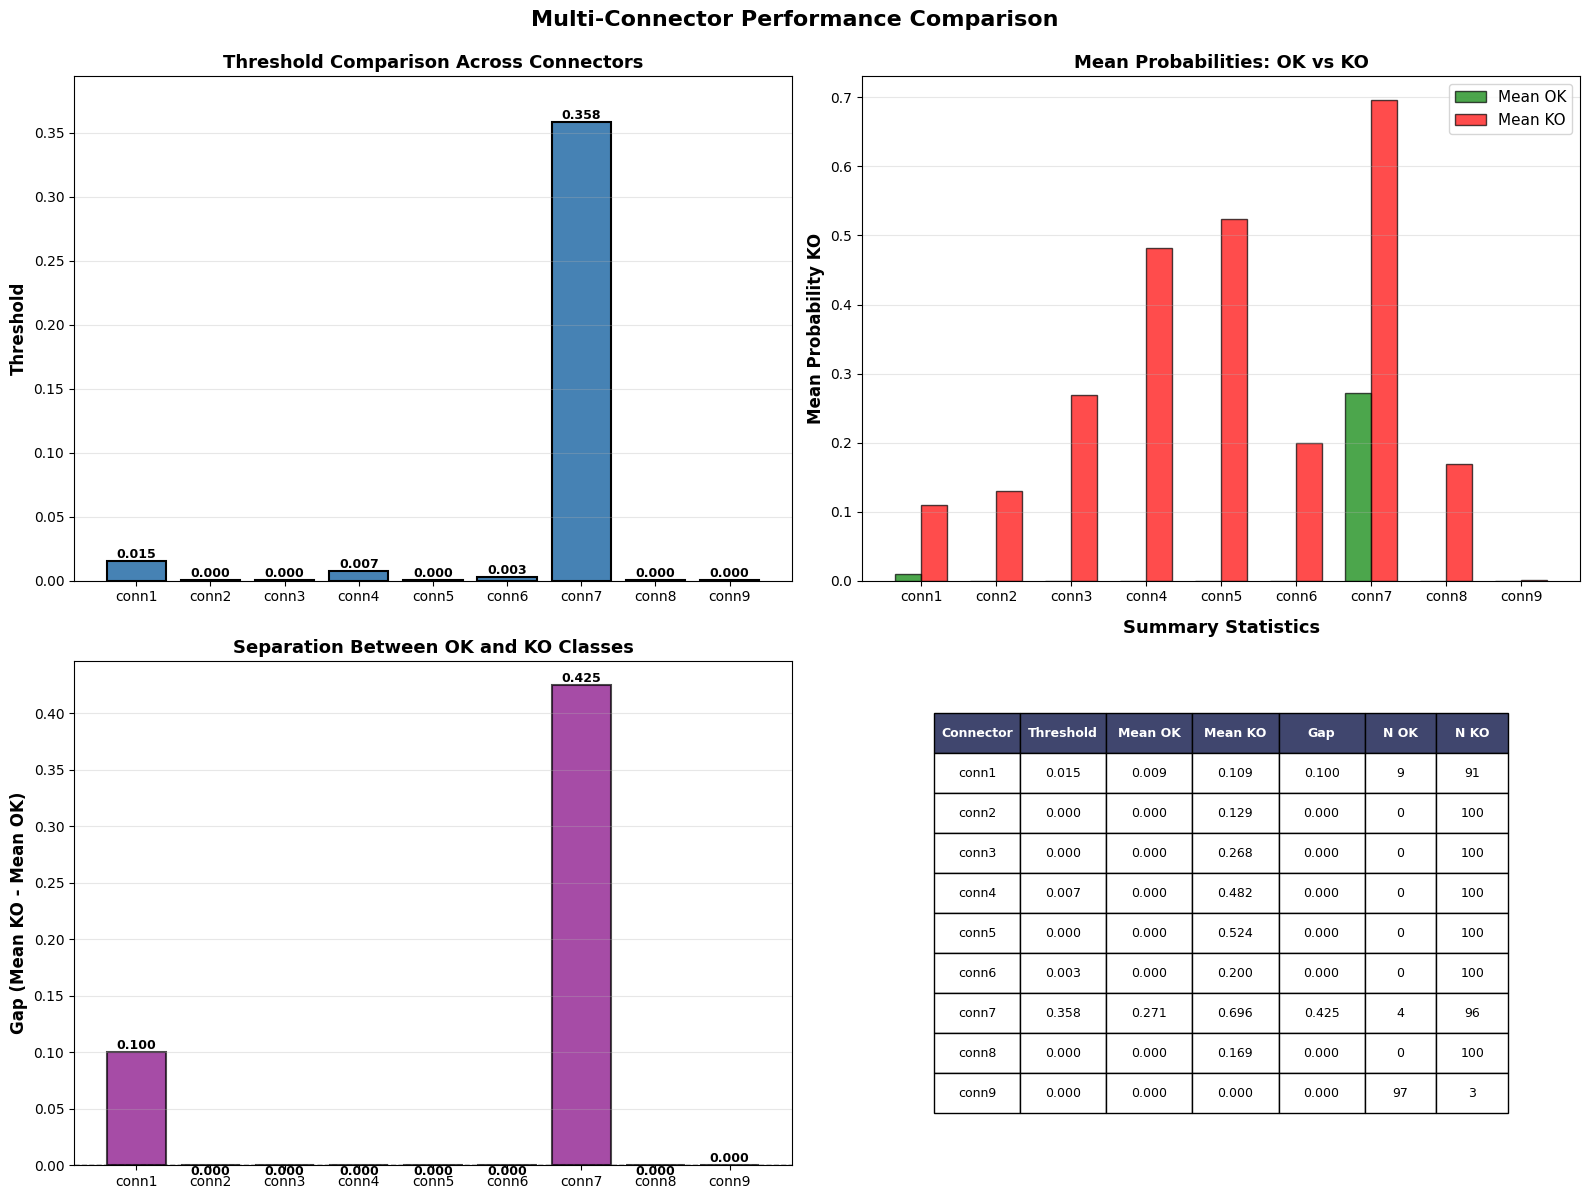

\n================================================================================
MULTI-CONNECTOR COMPARISON SUMMARY
Connector    Threshold    Mean OK      Mean KO      Gap          N OK     N KO    
--------------------------------------------------------------------------------
conn1        0.015        0.009        0.109        0.100        9        91      
conn2        0.000        0.000        0.129        0.000        0        100     
conn3        0.000        0.000        0.268        0.000        0        100     
conn4        0.007        0.000        0.482        0.000        0        100     
conn5        0.000        0.000        0.524        0.000        0        100     
conn6        0.003        0.000        0.200        0.000        0        100     
conn7        0.358        0.271        0.696        0.425        4        96      
conn8        0.000        0.000        0.169        0.000        0        100     
conn9        0.000        0.000        0.000        0.

In [81]:
# CELL I — Multi-Connector Comparison
# Compare performance across all trained connectors

try:
    # Get all trained connectors
    trained_connectors = []
    for conn_id in sorted(connector_masks.keys()):
        model_path = OUTPUT_ROOT / conn_id / "model.pt"
        threshold_path = OUTPUT_ROOT / conn_id / "threshold.json"
        if model_path.exists() and threshold_path.exists():
            trained_connectors.append(conn_id)

    if len(trained_connectors) == 0:
        print("No trained models found!")
    else:
        print(f"Found {len(trained_connectors)} trained connectors: {trained_connectors}")

        # Collect statistics for each connector
        connector_stats = []

        for conn_id in trained_connectors:
            try:
                model, threshold = load_trained_model(conn_id, OUTPUT_ROOT, device)
                info = connector_masks[conn_id]

                # Get image (from Data with KO folder for analysis)
                conn_dir = CONNECTORS_WITH_KO_ROOT / connector_id
                img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

                if len(img_files) == 0:
                    continue

                # Compute predictions
                probs = []
                predictions = []

                for img_path in tqdm(img_files[:100], desc=f"Processing {conn_id}"):  # Limit to 100 for speed
                    prob_ko, is_ko = predict_connector(
                        img_path, conn_id, model, info, threshold, device
                    )
                    probs.append(prob_ko)
                    predictions.append(is_ko)

                probs = np.array(probs)
                predictions = np.array(predictions)

                ok_probs = probs[~predictions]
                ko_probs = probs[predictions]

                connector_stats.append({
                    'connector': conn_id,
                    'threshold': threshold,
                    'mean_prob_ok': np.mean(ok_probs) if len(ok_probs) > 0 else 0,
                    'mean_prob_ko': np.mean(ko_probs) if len(ko_probs) > 0 else 0,
                    'std_prob_ok': np.std(ok_probs) if len(ok_probs) > 0 else 0,
                    'std_prob_ko': np.std(ko_probs) if len(ko_probs) > 0 else 0,
                    'n_ok': len(ok_probs),
                    'n_ko': len(ko_probs),
                    'gap': np.mean(ko_probs) - np.mean(ok_probs) if len(ok_probs) > 0 and len(ko_probs) > 0 else 0
                })

            except Exception as e:
                print(f"Error processing {conn_id}: {e}")
                continue

        if len(connector_stats) == 0:
            print("No statistics collected!")
        else:
            # Create comparison visualization
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))

            connectors = [s['connector'] for s in connector_stats]
            thresholds = [s['threshold'] for s in connector_stats]
            mean_ok = [s['mean_prob_ok'] for s in connector_stats]
            mean_ko = [s['mean_prob_ko'] for s in connector_stats]
            std_ok = [s['std_prob_ok'] for s in connector_stats]
            std_ko = [s['std_prob_ko'] for s in connector_stats]
            gaps = [s['gap'] for s in connector_stats]

            # Plot 1: Thresholds comparison
            ax1 = axes[0, 0]
            bars = ax1.bar(connectors, thresholds, color='steelblue', edgecolor='black', linewidth=1.5)
            ax1.set_ylabel('Threshold', fontsize=12, weight='bold')
            ax1.set_title('Threshold Comparison Across Connectors', fontsize=13, weight='bold')
            ax1.grid(True, alpha=0.3, axis='y')
            ax1.set_ylim([0, max(thresholds) * 1.1])

            # Add value labels on bars
            for bar, val in zip(bars, thresholds):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, weight='bold')

            # Plot 2: Mean probabilities
            ax2 = axes[0, 1]
            x = np.arange(len(connectors))
            width = 0.35
            bars1 = ax2.bar(x - width/2, mean_ok, width, label='Mean OK',
                           color='green', alpha=0.7, edgecolor='black')
            bars2 = ax2.bar(x + width/2, mean_ko, width, label='Mean KO',
                           color='red', alpha=0.7, edgecolor='black')
            ax2.set_ylabel('Mean Probability KO', fontsize=12, weight='bold')
            ax2.set_title('Mean Probabilities: OK vs KO', fontsize=13, weight='bold')
            ax2.set_xticks(x)
            ax2.set_xticklabels(connectors)
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3, axis='y')

            # Plot 3: Gap between OK and KO
            ax3 = axes[1, 0]
            bars = ax3.bar(connectors, gaps, color='purple', alpha=0.7, edgecolor='black', linewidth=1.5)
            ax3.set_ylabel('Gap (Mean KO - Mean OK)', fontsize=12, weight='bold')
            ax3.set_title('Separation Between OK and KO Classes', fontsize=13, weight='bold')
            ax3.axhline(0, color='black', linestyle='--', linewidth=1)
            ax3.grid(True, alpha=0.3, axis='y')

            # Add value labels
            for bar, val in zip(bars, gaps):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.3f}', ha='center',
                        va='bottom' if height > 0 else 'top', fontsize=9, weight='bold')

            # Plot 4: Summary table
            ax4 = axes[1, 1]
            ax4.axis('off')

            table_data = []
            headers = ['Connector', 'Threshold', 'Mean OK', 'Mean KO', 'Gap', 'N OK', 'N KO']

            for s in connector_stats:
                table_data.append([
                    s['connector'],
                    f"{s['threshold']:.3f}",
                    f"{s['mean_prob_ok']:.3f}",
                    f"{s['mean_prob_ko']:.3f}",
                    f"{s['gap']:.3f}",
                    s['n_ok'],
                    s['n_ko']
                ])

            table = ax4.table(cellText=table_data, colLabels=headers,
                            cellLoc='center', loc='center',
                            colWidths=[0.12, 0.12, 0.12, 0.12, 0.12, 0.1, 0.1])
            table.auto_set_font_size(False)
            table.set_fontsize(9)
            table.scale(1, 2)

            # Style header
            for i in range(len(headers)):
                table[(0, i)].set_facecolor('#40466e')
                table[(0, i)].set_text_props(weight='bold', color='white')

            ax4.set_title('Summary Statistics', fontsize=13, weight='bold', pad=20)

            plt.suptitle('Multi-Connector Performance Comparison',
                        fontsize=16, weight='bold', y=0.995)
            plt.tight_layout()
            plt.show()

            # Print summary
            print("\\n" + "="*80)
            print("MULTI-CONNECTOR COMPARISON SUMMARY")
            print("="*80)
            print(f"{'Connector':<12} {'Threshold':<12} {'Mean OK':<12} {'Mean KO':<12} {'Gap':<12} {'N OK':<8} {'N KO':<8}")
            print("-"*80)
            for s in connector_stats:
                print(f"{s['connector']:<12} {s['threshold']:<12.3f} {s['mean_prob_ok']:<12.3f} "
                     f"{s['mean_prob_ko']:<12.3f} {s['gap']:<12.3f} {s['n_ok']:<8} {s['n_ko']:<8}")
            print("="*80)

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Visualizing feature maps for: 20251106142557_TOP.png
Layer: layer4
Feature maps shape: (512, 4, 10)
Number of channels: 512


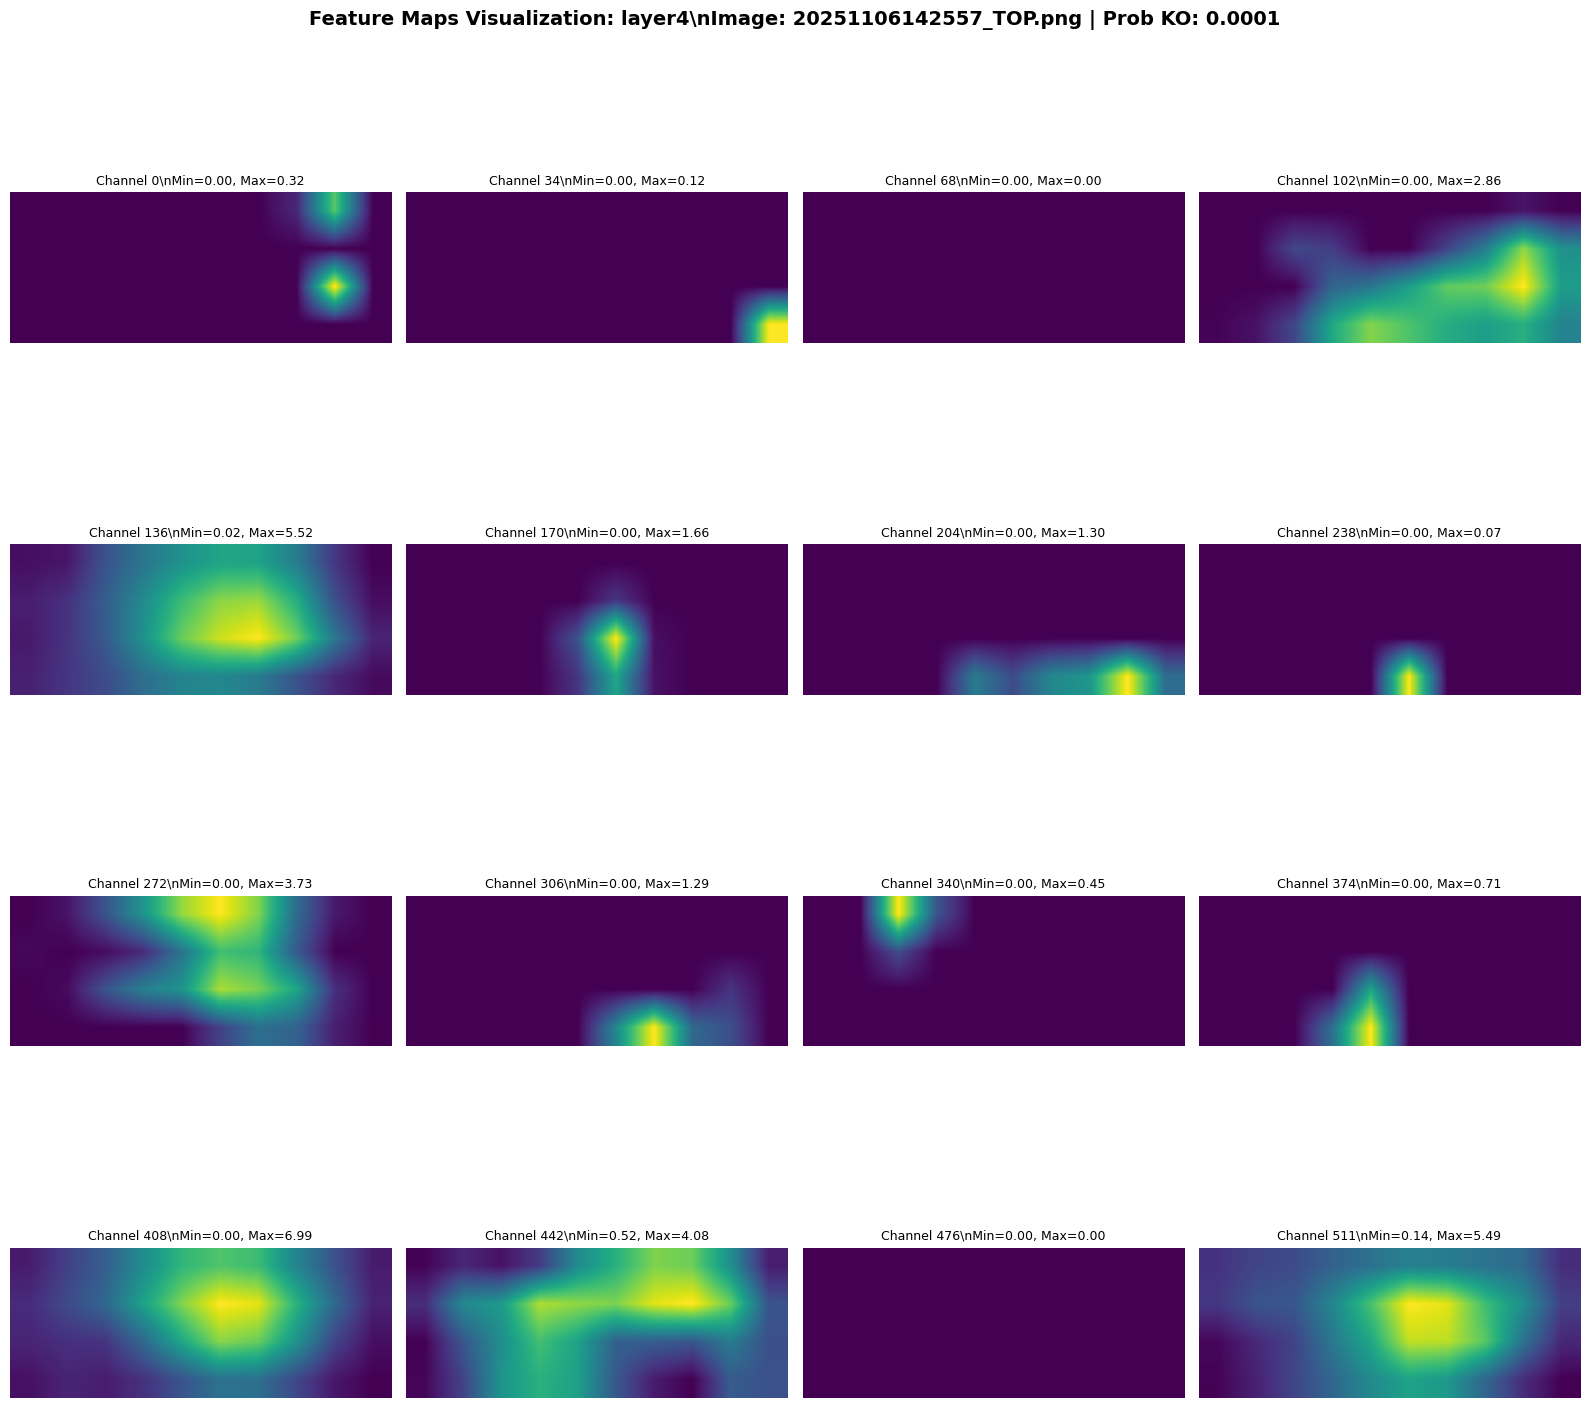

\n============================================================
FEATURE MAP STATISTICS
Layer: layer4
Shape: (512, 4, 10)
Mean activation: 0.8195
Std activation: 1.2632
Min/Max: 0.0000 / 7.9774


In [82]:
# CELL J — Feature Map Visualization
# Visualize intermediate feature maps from the model

connector_id = "conn2"  # Change this
image_path = None  # Set to specific image path, or None to pick random
layer_name = "layer4"  # Options: "layer1", "layer2", "layer3", "layer4"

try:
    # Load model
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get image (from Data with KO folder for analysis)
    conn_dir = CONNECTORS_WITH_KO_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    if image_path is None:
        import random
        image_path = random.choice(img_files)

    image_path = Path(image_path)

    if not image_path.exists():
        print(f"Image not found: {image_path}")
    else:
        print(f"Visualizing feature maps for: {image_path.name}")
        print(f"Layer: {layer_name}")

        # Load and preprocess image
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(image_path).convert('L'))

        # Preprocess for model
        img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(device)

        # Register hook to capture feature maps
        feature_maps = []

        def hook_fn(module, input, output):
            feature_maps.append(output.detach().cpu().numpy())

        # Get target layer
        if layer_name == "layer1":
            target_layer = model.backbone.layer1
        elif layer_name == "layer2":
            target_layer = model.backbone.layer2
        elif layer_name == "layer3":
            target_layer = model.backbone.layer3
        elif layer_name == "layer4":
            target_layer = model.backbone.layer4
        else:
            print(f"Unknown layer: {layer_name}")
            target_layer = model.backbone.layer4

        # Register hook
        handle = target_layer.register_forward_hook(hook_fn)

        # Forward pass
        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            prob_ko = torch.sigmoid(output).item()

        # Remove hook
        handle.remove()

        if len(feature_maps) == 0:
            print("No feature maps captured!")
        else:
            # Get feature maps
            fmaps = feature_maps[0][0]  # [C, H, W]
            n_channels = fmaps.shape[0]

            print(f"Feature maps shape: {fmaps.shape}")
            print(f"Number of channels: {n_channels}")

            # Visualize top 16 feature maps
            n_show = min(16, n_channels)
            selected_channels = np.linspace(0, n_channels-1, n_show, dtype=int)

            fig, axes = plt.subplots(4, 4, figsize=(16, 16))
            axes = axes.flatten()

            for idx, ch_idx in enumerate(selected_channels):
                fmap = fmaps[ch_idx]

                # Normalize
                fmap_norm = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)

                # Resize to original image size for better visualization
                fmap_resized = cv2.resize(fmap_norm, (img.shape[1], img.shape[0]))

                axes[idx].imshow(fmap_resized, cmap='viridis')
                axes[idx].set_title(f"Channel {ch_idx}\\nMin={fmap.min():.2f}, Max={fmap.max():.2f}",
                                   fontsize=9)
                axes[idx].axis('off')

            plt.suptitle(f"Feature Maps Visualization: {layer_name}\\n"
                        f"Image: {image_path.name} | Prob KO: {prob_ko:.4f}",
                        fontsize=14, weight='bold')
            plt.tight_layout()
            plt.show()

            # Show statistics
            print("\\n" + "="*60)
            print("FEATURE MAP STATISTICS")
            print("="*60)
            print(f"Layer: {layer_name}")
            print(f"Shape: {fmaps.shape}")
            print(f"Mean activation: {np.mean(fmaps):.4f}")
            print(f"Std activation: {np.std(fmaps):.4f}")
            print(f"Min/Max: {np.min(fmaps):.4f} / {np.max(fmaps):.4f}")
            print("="*60)

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

ANALISI CELLE DIFETTOSE

Loading ground truth labels from CSV...
Computing predictions for 208 images...


100%|██████████| 208/208 [00:03<00:00, 53.59it/s]
/tmp/ipython-input-3367754000.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


\n======================================================================
MISCLASSIFICATION ANALYSIS FOR CONN6
Threshold: 0.0026
\nConfusion Matrix Summary:
  True Negatives (OK→OK):  203
  False Positives (OK→KO): 1  ⚠️  FALSI KO
  False Negatives (KO→OK): 3  ⚠️  FALSI OK
  True Positives (KO→KO):  1
\n======================================================================
FALSE POSITIVES (FALSI KO): 1 OK images predicted as KO
These OK images have prob_ko >= threshold (0.0026)
Showing all 1 false positives with Grad-CAM...


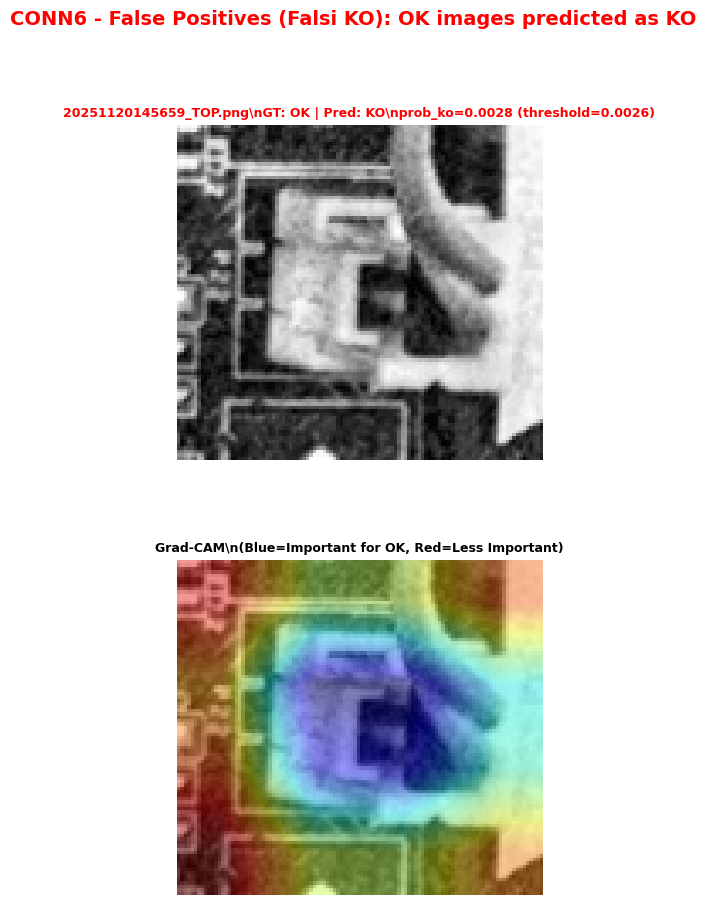

\nFalse Positive Statistics:
  Min prob_ko: 0.0028
  Max prob_ko: 0.0028
  Mean prob_ko: 0.0028
  Std prob_ko: 0.0000
\n======================================================================
FALSE NEGATIVES (FALSI OK): 3 KO images predicted as OK
These KO images have prob_ko < threshold (0.0026)
Showing all 3 false negatives with Grad-CAM...


/tmp/ipython-input-3367754000.py:305: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


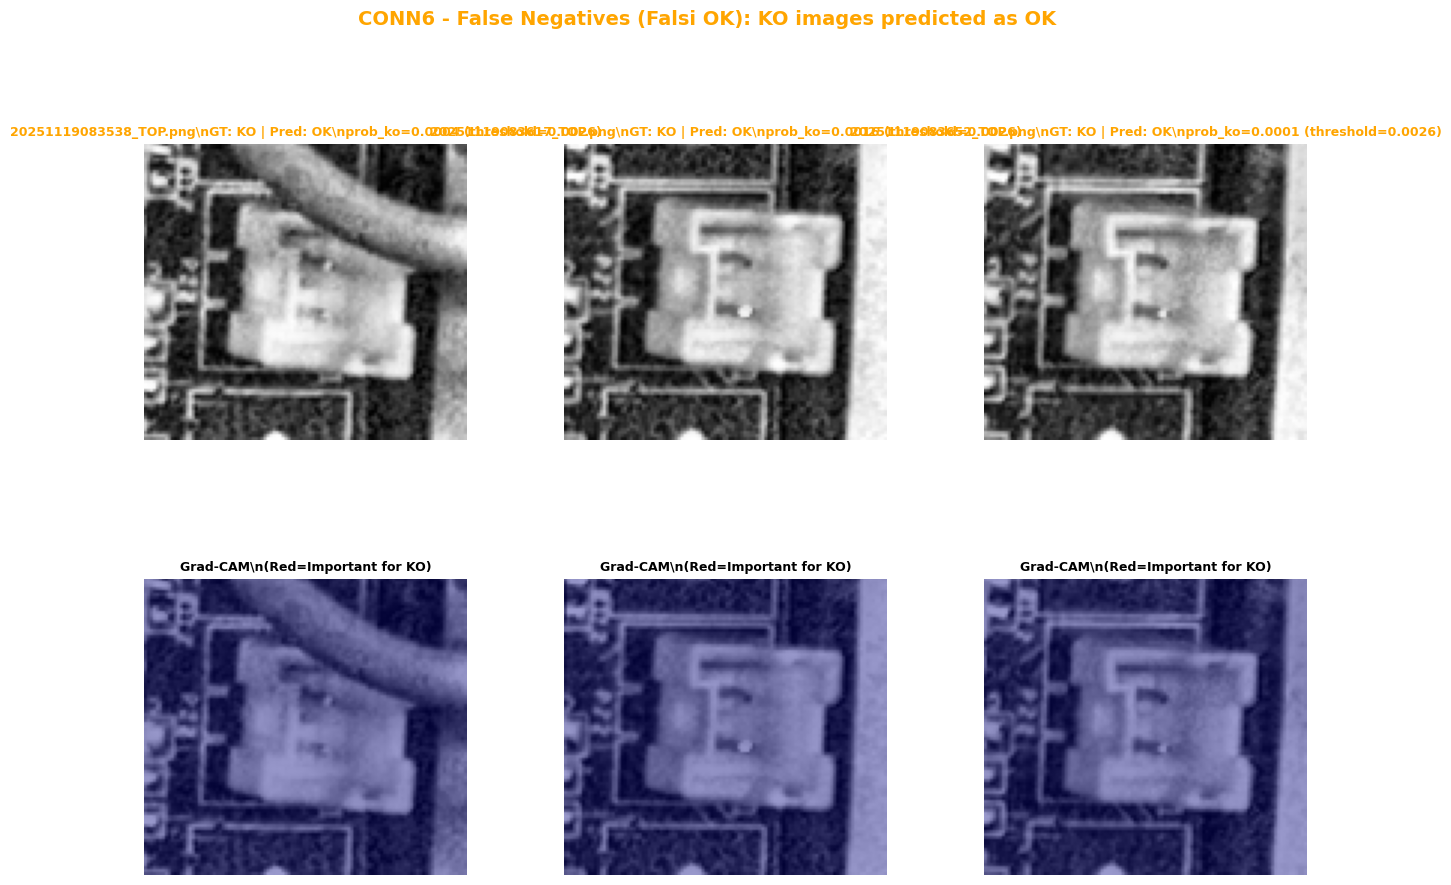

\nFalse Negative Statistics:
  Min prob_ko: 0.0001
  Max prob_ko: 0.0016
  Mean prob_ko: 0.0007
  Std prob_ko: 0.0006
\n======================================================================
REFERENCE: Correctly Classified Samples


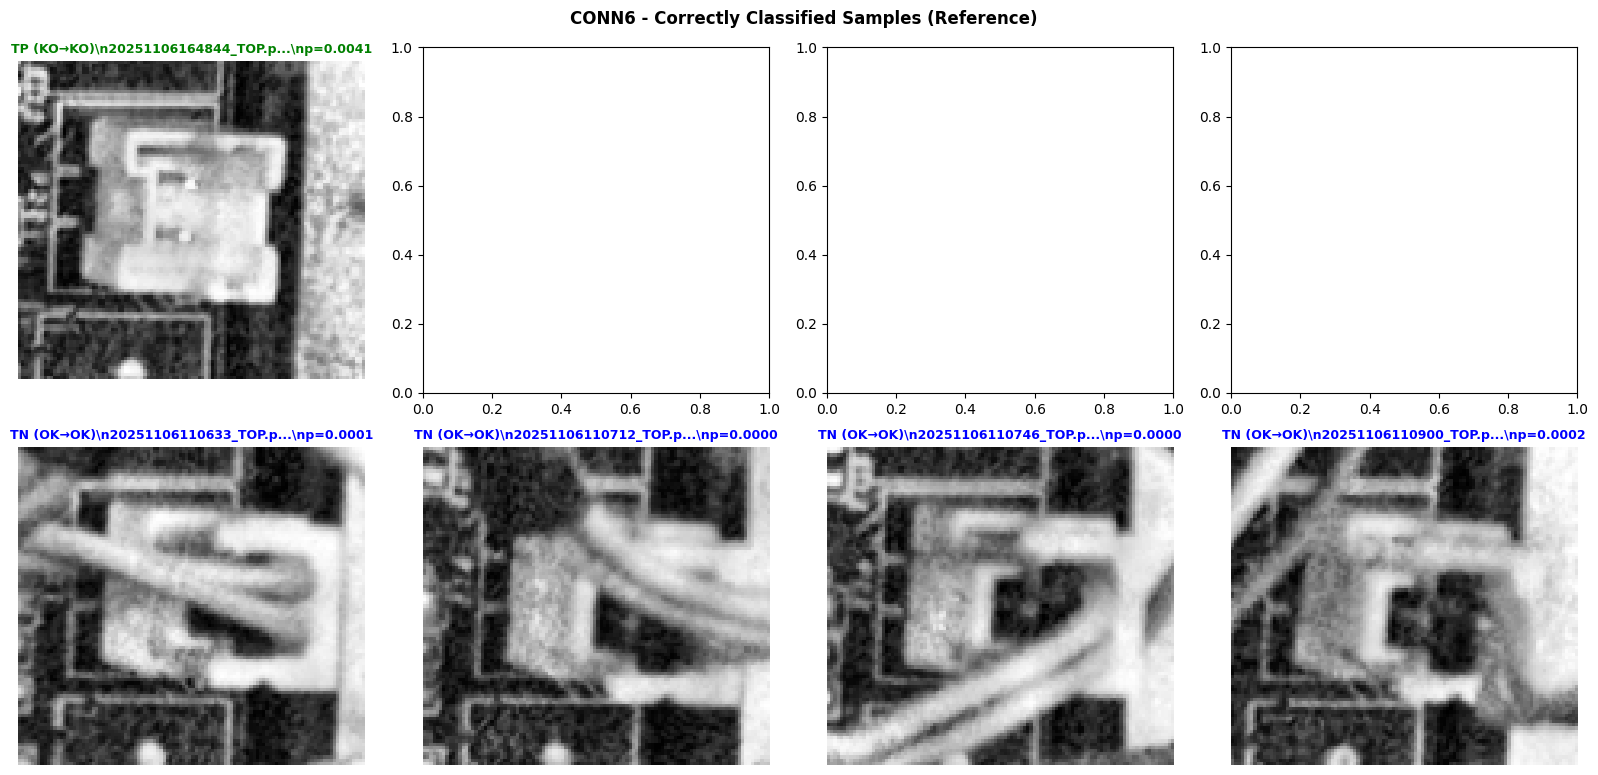

\n======================================================================
ANALYSIS COMPLETE
\nKey Insights:
  • 1 OK images are being classified as KO
    → Consider lowering threshold or improving OK feature learning
  • 3 KO images are being classified as OK
    → Consider raising threshold or improving KO feature learning


In [77]:
# CELL K — Misclassification Analysis: False Positives & False Negatives
# Analyze false positives (OK predicted as KO) and false negatives (KO predicted as OK)
# Helps identify where the model is making mistakes

connector_id = "conn6"  # Change this
csv_path = BASE_DIR / "features_labeled.csv"  # Path to labeled CSV

try:
    from sklearn.metrics import confusion_matrix
    import pandas as pd
    from matplotlib.gridspec import GridSpec

    # Load model and threshold
    model, threshold = load_trained_model(connector_id, OUTPUT_ROOT, device)
    info = connector_masks[connector_id]

    # Get images (from Data with KO folder for analysis)
    conn_dir = CONNECTORS_WITH_KO_ROOT / connector_id
    img_files = sorted(list(conn_dir.glob("*.png")) + list(conn_dir.glob("*.jpg")))

    if len(img_files) == 0:
        print(f"No images found in {conn_dir}")
    else:
        # Load ground truth labels from CSV
        print(f"Loading ground truth labels from CSV...")
        df_gt = pd.read_csv(csv_path)

        # Filter for current connector and only OK/KO (exclude OCCLUSION)
        df_conn = df_gt[
            (df_gt['connector_name'] == connector_id) &
            (df_gt['label'].isin(['OK', 'KO']))
        ].copy()

        # Create mapping: filename -> label
        filename_to_label = {}
        for _, row in df_conn.iterrows():
            csv_filename = row['filename']
            label = row['label']
            filename_to_label[csv_filename] = label

        # Compute predictions and collect misclassifications
        print(f"Computing predictions for {len(img_files)} images...")
        false_positives = []  # OK predicted as KO
        false_negatives = []  # KO predicted as OK
        true_positives = []   # KO predicted as KO
        true_negatives = []   # OK predicted as OK

        for img_path in tqdm(img_files):
            img_filename = img_path.name

            if img_filename not in filename_to_label:
                continue

            gt_label = filename_to_label[img_filename]
            prob_ko, is_ko = predict_connector(img_path, connector_id, model, info, threshold, device)
            pred_label = "KO" if is_ko else "OK"

            # Classify into confusion matrix categories
            if gt_label == "OK" and pred_label == "KO":
                false_positives.append({
                    'path': img_path,
                    'prob_ko': prob_ko,
                    'gt_label': gt_label,
                    'pred_label': pred_label
                })
            elif gt_label == "KO" and pred_label == "OK":
                false_negatives.append({
                    'path': img_path,
                    'prob_ko': prob_ko,
                    'gt_label': gt_label,
                    'pred_label': pred_label
                })
            elif gt_label == "KO" and pred_label == "KO":
                true_positives.append({
                    'path': img_path,
                    'prob_ko': prob_ko,
                    'gt_label': gt_label,
                    'pred_label': pred_label
                })
            elif gt_label == "OK" and pred_label == "OK":
                true_negatives.append({
                    'path': img_path,
                    'prob_ko': prob_ko,
                    'gt_label': gt_label,
                    'pred_label': pred_label
                })

        # Print summary
        print(f"\\n" + "="*70)
        print(f"MISCLASSIFICATION ANALYSIS FOR {connector_id.upper()}")
        print("="*70)
        print(f"Threshold: {threshold:.4f}")
        print(f"\\nConfusion Matrix Summary:")
        print(f"  True Negatives (OK→OK):  {len(true_negatives)}")
        print(f"  False Positives (OK→KO): {len(false_positives)}  ⚠️  FALSI KO")
        print(f"  False Negatives (KO→OK): {len(false_negatives)}  ⚠️  FALSI OK")
        print(f"  True Positives (KO→KO):  {len(true_positives)}")
        print("="*70)

        # Grad-CAM function (reuse from CELL G)
        def generate_gradcam_detailed(model, image_tensor, target_layer, device, is_ko_prediction):
            """Generate Grad-CAM heatmap."""
            model.eval()

            gradients = []
            activations = []

            def backward_hook(module, grad_input, grad_output):
                if grad_output[0] is not None:
                    gradients.append(grad_output[0].detach())

            def forward_hook(module, input, output):
                activations.append(output.detach())

            try:
                hook_handle = target_layer.register_full_backward_hook(backward_hook)
            except:
                hook_handle = target_layer.register_backward_hook(backward_hook)

            forward_handle = target_layer.register_forward_hook(forward_hook)

            output = model(image_tensor)
            prob_ko = torch.sigmoid(output).item()

            model.zero_grad()

            if is_ko_prediction:
                prob_tensor = torch.sigmoid(output)
                prob_tensor.backward()
            else:
                prob_tensor = torch.sigmoid(output)
                prob_ok_tensor = 1.0 - prob_tensor
                prob_ok_tensor.backward()

            if len(gradients) == 0 or len(activations) == 0:
                hook_handle.remove()
                forward_handle.remove()
                return None, prob_ko

            grads = gradients[0]
            acts = activations[0]

            weights = torch.mean(grads, dim=(2, 3), keepdim=True)
            cam = torch.sum(weights * acts, dim=1, keepdim=True)
            cam = torch.relu(cam)

            cam = cam.squeeze().detach().cpu().numpy()
            if cam.max() > cam.min():
                cam = (cam - cam.min()) / (cam.max() - cam.min())
            else:
                cam = np.zeros_like(cam)

            h, w = image_tensor.shape[2], image_tensor.shape[3]
            cam_resized = cv2.resize(cam, (w, h))

            hook_handle.remove()
            forward_handle.remove()

            return cam_resized, prob_ko

        # Visualize False Positives (Falsi KO)
        if len(false_positives) > 0:
            print(f"\\n" + "="*70)
            print(f"FALSE POSITIVES (FALSI KO): {len(false_positives)} OK images predicted as KO")
            print("="*70)
            print(f"These OK images have prob_ko >= threshold ({threshold:.4f})")
            print(f"Showing all {len(false_positives)} false positives with Grad-CAM...")

            n_fp = len(false_positives)
            n_cols = min(4, n_fp)
            n_rows = (n_fp + n_cols - 1) // n_cols

            fig = plt.figure(figsize=(5*n_cols, 10*n_rows))
            gs = GridSpec(n_rows * 2, n_cols, figure=fig, hspace=0.3, wspace=0.3)

            target_layer = model.backbone.layer4

            for idx, sample in enumerate(false_positives):
                img_path = sample['path']
                prob_ko = sample['prob_ko']

                # Load image
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                # Preprocess for model
                img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
                img_tensor = img_tensor.to(device)

                # Generate Grad-CAM (for OK image, backward on prob_ok)
                heatmap, _ = generate_gradcam_detailed(model, img_tensor, target_layer, device, is_ko_prediction=False)

                row = (idx // n_cols) * 2
                col = idx % n_cols

                # Original image
                ax1 = fig.add_subplot(gs[row, col])
                ax1.imshow(img, cmap='gray')
                ax1.set_title(f"{img_path.name}\\nGT: OK | Pred: KO\\nprob_ko={prob_ko:.4f} (threshold={threshold:.4f})",
                            fontsize=9, color='red', weight='bold')
                ax1.axis('off')
                # Red border
                for spine in ax1.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)

                # Grad-CAM overlay
                if heatmap is not None:
                    ax2 = fig.add_subplot(gs[row+1, col])
                    # Inverted colormap: Red = Less Known, Blue = Better Known
                    heatmap_inv = 1.0 - heatmap
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
                    heatmap_colored = plt.cm.jet(heatmap_inv)[:, :, :3]
                    overlay = 0.6 * img_rgb + 0.4 * heatmap_colored
                    ax2.imshow(overlay)
                    ax2.set_title("Grad-CAM\\n(Blue=Important for OK, Red=Less Important)",
                                fontsize=9, weight='bold')
                    ax2.axis('off')
                else:
                    ax2 = fig.add_subplot(gs[row+1, col])
                    ax2.text(0.5, 0.5, "Grad-CAM\\nError", ha='center', va='center')
                    ax2.axis('off')

            plt.suptitle(f'{connector_id.upper()} - False Positives (Falsi KO): OK images predicted as KO',
                        fontsize=14, weight='bold', color='red', y=0.995)
            plt.tight_layout()
            plt.show()

            # Statistics
            fp_probs = [s['prob_ko'] for s in false_positives]
            print(f"\\nFalse Positive Statistics:")
            print(f"  Min prob_ko: {np.min(fp_probs):.4f}")
            print(f"  Max prob_ko: {np.max(fp_probs):.4f}")
            print(f"  Mean prob_ko: {np.mean(fp_probs):.4f}")
            print(f"  Std prob_ko: {np.std(fp_probs):.4f}")
        else:
            print(f"\\n✅ No false positives found!")

        # Visualize False Negatives (Falsi OK)
        if len(false_negatives) > 0:
            print(f"\\n" + "="*70)
            print(f"FALSE NEGATIVES (FALSI OK): {len(false_negatives)} KO images predicted as OK")
            print("="*70)
            print(f"These KO images have prob_ko < threshold ({threshold:.4f})")
            print(f"Showing all {len(false_negatives)} false negatives with Grad-CAM...")

            n_fn = len(false_negatives)
            n_cols = min(4, n_fn)
            n_rows = (n_fn + n_cols - 1) // n_cols

            fig = plt.figure(figsize=(5*n_cols, 10*n_rows))
            gs = GridSpec(n_rows * 2, n_cols, figure=fig, hspace=0.3, wspace=0.3)

            target_layer = model.backbone.layer4

            for idx, sample in enumerate(false_negatives):
                img_path = sample['path']
                prob_ko = sample['prob_ko']

                # Load image
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                # Preprocess for model
                img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
                img_tensor = img_tensor.to(device)

                # Generate Grad-CAM (for KO image, backward on prob_ko)
                heatmap, _ = generate_gradcam_detailed(model, img_tensor, target_layer, device, is_ko_prediction=True)

                row = (idx // n_cols) * 2
                col = idx % n_cols

                # Original image
                ax1 = fig.add_subplot(gs[row, col])
                ax1.imshow(img, cmap='gray')
                ax1.set_title(f"{img_path.name}\\nGT: KO | Pred: OK\\nprob_ko={prob_ko:.4f} (threshold={threshold:.4f})",
                            fontsize=9, color='orange', weight='bold')
                ax1.axis('off')
                # Orange border
                for spine in ax1.spines.values():
                    spine.set_edgecolor('orange')
                    spine.set_linewidth(3)

                # Grad-CAM overlay
                if heatmap is not None:
                    ax2 = fig.add_subplot(gs[row+1, col])
                    # Standard colormap: Red = Important for KO
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0
                    heatmap_colored = plt.cm.jet(heatmap)[:, :, :3]
                    overlay = 0.6 * img_rgb + 0.4 * heatmap_colored
                    ax2.imshow(overlay)
                    ax2.set_title("Grad-CAM\\n(Red=Important for KO)",
                                fontsize=9, weight='bold')
                    ax2.axis('off')
                else:
                    ax2 = fig.add_subplot(gs[row+1, col])
                    ax2.text(0.5, 0.5, "Grad-CAM\\nError", ha='center', va='center')
                    ax2.axis('off')

            plt.suptitle(f'{connector_id.upper()} - False Negatives (Falsi OK): KO images predicted as OK',
                        fontsize=14, weight='bold', color='orange', y=0.995)
            plt.tight_layout()
            plt.show()

            # Statistics
            fn_probs = [s['prob_ko'] for s in false_negatives]
            print(f"\\nFalse Negative Statistics:")
            print(f"  Min prob_ko: {np.min(fn_probs):.4f}")
            print(f"  Max prob_ko: {np.max(fn_probs):.4f}")
            print(f"  Mean prob_ko: {np.mean(fn_probs):.4f}")
            print(f"  Std prob_ko: {np.std(fn_probs):.4f}")
        else:
            print(f"\\n✅ No false negatives found!")

        # Comparison: Show some correctly classified samples for reference
        if len(true_positives) > 0 or len(true_negatives) > 0:
            print(f"\\n" + "="*70)
            print(f"REFERENCE: Correctly Classified Samples")
            print("="*70)

            # Show a few true positives (KO→KO) and true negatives (OK→OK)
            n_ref = min(4, max(len(true_positives), len(true_negatives)))

            fig, axes = plt.subplots(2, n_ref, figsize=(4*n_ref, 8))
            if n_ref == 1:
                axes = axes.reshape(-1, 1)

            # True Positives (KO→KO)
            for idx in range(min(n_ref, len(true_positives))):
                sample = true_positives[idx]
                img_path = sample['path']
                prob_ko = sample['prob_ko']

                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                axes[0, idx].imshow(img, cmap='gray')
                axes[0, idx].set_title(f"TP (KO→KO)\\n{img_path.name[:20]}...\\np={prob_ko:.4f}",
                                      fontsize=9, color='green', weight='bold')
                axes[0, idx].axis('off')
                for spine in axes[0, idx].spines.values():
                    spine.set_edgecolor('green')
                    spine.set_linewidth(2)

            # True Negatives (OK→OK)
            for idx in range(min(n_ref, len(true_negatives))):
                sample = true_negatives[idx]
                img_path = sample['path']
                prob_ko = sample['prob_ko']

                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    img = np.array(Image.open(img_path).convert('L'))

                axes[1, idx].imshow(img, cmap='gray')
                axes[1, idx].set_title(f"TN (OK→OK)\\n{img_path.name[:20]}...\\np={prob_ko:.4f}",
                                      fontsize=9, color='blue', weight='bold')
                axes[1, idx].axis('off')
                for spine in axes[1, idx].spines.values():
                    spine.set_edgecolor('blue')
                    spine.set_linewidth(2)

            plt.suptitle(f'{connector_id.upper()} - Correctly Classified Samples (Reference)',
                        fontsize=12, weight='bold', y=0.98)
            plt.tight_layout()
            plt.show()

        print(f"\\n" + "="*70)
        print("ANALYSIS COMPLETE")
        print("="*70)
        print(f"\\nKey Insights:")
        if len(false_positives) > 0:
            print(f"  • {len(false_positives)} OK images are being classified as KO")
            print(f"    → Consider lowering threshold or improving OK feature learning")
        if len(false_negatives) > 0:
            print(f"  • {len(false_negatives)} KO images are being classified as OK")
            print(f"    → Consider raising threshold or improving KO feature learning")
        if len(false_positives) == 0 and len(false_negatives) == 0:
            print(f"  • Perfect classification! No misclassifications found.")
        print("="*70)

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()